In [86]:
import pandas as pd
import numpy as np
import nibabel as nib
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from neuroaging.utils.utils import compute_poststrat_weights

(np.float64(-0.5), np.float64(255.5), np.float64(0.5), np.float64(-0.5))

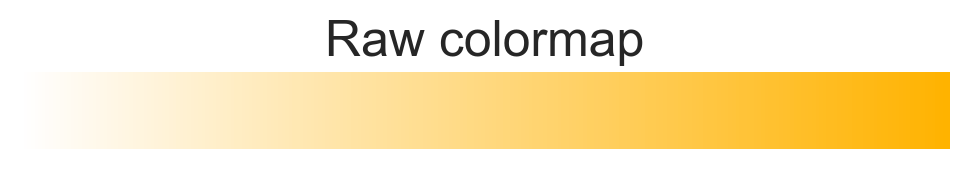

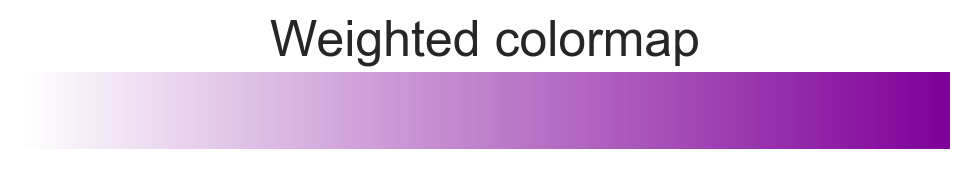

In [87]:
# ── Global visualisation configuration ──────────────────────────────────────

# 1.  General Matplotlib defaults
# ── Global visualisation configuration ──────────────────────────────────────
import matplotlib as mpl
import seaborn as sns

mpl.rcParams.update(
    {
        # ── Canvas size & resolution ───────────────────────────────────────────
        # Default figure size: 12×8 inches  →  4800×3200 px when exported at 400 dpi
        "figure.figsize": (12, 8),
        "figure.dpi": 200,  # crisp in-notebook / retina preview
        "savefig.dpi": 400,  # print-quality PNG/PDF
        # ── Fonts ──────────────────────────────────────────────────────────────
        "font.family": "sans-serif",
        "font.sans-serif": ["Roboto", "DejaVu Sans", "Arial"],
        "axes.titlesize": 24,
        # "axes.titleweight": "bold",
        "axes.labelsize": 24,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 20,
        # ── Axis & spine aesthetics ────────────────────────────────────────────
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.spines.left": True,
        "axes.spines.bottom": True,
        "axes.linewidth": 1,
        "axes.grid": True,
        "grid.color": "#E6E6E6",
        "grid.linewidth": 0.4,
        "grid.alpha": 0.8,
        # ── Colour cycle (colour-blind-safe) ───────────────────────────────────
        "axes.prop_cycle": mpl.cycler(color=sns.color_palette("Set2")),
        # ── Figure background ─────────────────────────────────────────────────
        "figure.facecolor": "white",
    }
)

# Seaborn theme inherits the rcParams above
sns.set_theme(context="talk", style="whitegrid", palette="Set2")


# 2.  Seaborn theme (inherits Matplotlib rcParams)
sns.set_theme(
    context="talk",  # slightly larger fonts for presentations / papers
    style="whitegrid",  # grid only on y-axis (good for histograms)
    palette="Set2",  # matches the rcParams colour cycle
)


# 3.  Helper function for consistent figure export
def savefig_nice(fig, filename, *, tight=True, dpi=300, **savefig_kwargs):
    """Save figure with tight layout and correct DPI."""
    if tight:
        fig.tight_layout()
    fig.savefig(filename, dpi=dpi, bbox_inches="tight", transparent=True, **savefig_kwargs)


# 4.  Colour constants for this project (optional convenience)
# COL_RAW = "#1f77b4"  # e.g. unweighted sample
COL_RAW = "#ffb300"
# COL_WEIGHTED = "#d62728"  # weighted sample
COL_WEIGHTED = "#7F0099CE"  # weighted sample
COL_REF = "0.25"  # census reference (neutral grey)
COL_CENSUS = "#A5A5A5"

# generate colormaps from white to colour
COL_WHITE = "white"
COL_RAW_RGB = mpl.colors.to_rgb(COL_RAW)
COL_WEIGHTED_RGB = mpl.colors.to_rgb(COL_WEIGHTED)
CMAP_RAW = mpl.colors.LinearSegmentedColormap.from_list("raw", [COL_WHITE, COL_RAW_RGB], N=256)
CMAP_WEIGHTED = mpl.colors.LinearSegmentedColormap.from_list(
    "weighted", [COL_WHITE, COL_WEIGHTED_RGB], N=256
)
# visualize the colormaps
# if __name__ == "__main__":
fig, ax = plt.subplots(figsize=(6, 0.5))
ax.imshow(np.linspace(0, 1, 256)[None, :], aspect="auto", cmap=CMAP_RAW)
ax.set_title("Raw colormap")
ax.axis("off")
# savefig_nice(fig, "colormap_raw.png")

fig, ax = plt.subplots(figsize=(6, 0.5))
ax.imshow(np.linspace(0, 1, 256)[None, :], aspect="auto", cmap=CMAP_WEIGHTED)
ax.set_title("Weighted colormap")
ax.axis("off")
# savefig_nice(fig, "colormap_weighted.png")

In [88]:
# Tell the pipeline which side of the parabola is “structural stabilisation”
orientation = {  # feel free to expand
    "gm_vol": "min",  # concave-down expected
    "adc": "max",  # concave-up expected
    # "fa"   : "min",
    # "rd"   : "min",
}


def vertex_age(beta1, beta2):
    """Age at vertex of a quadratic   β0 + β1·x + β2·x²."""
    return -beta1 / (2 * beta2)


def stabilisation_age(metric, betas, pvalues, *, age_min=18, age_max=85, orientation=orientation):
    """
    betas = dict with keys "age" (β1) and "age_sq" (β2)
    Returns (age*, flagged)   where flagged=True if outside range or wrong shape.
    """
    want = orientation.get(metric, "min")  # default = 'min' if not listed
    β1, β2 = betas["age"], betas["age_sq"]
    p1, p2 = pvalues["age"], pvalues["age_sq"]
    # ── 1. Shape check  ────────────────────────────────────────────────
    if (p2 > 0.05) or (want == "min" and β2 <= 0):
        # parabola opens down – no minimum inside; flag & push to boundary
        return age_min, True
    elif (p2 > 0.05) or (want == "max" and β2 >= 0):
        # parabola opens up – no maximum inside
        return age_max, True

    # ── 2. Compute vertex  ─────────────────────────────────────────────
    age_star = vertex_age(β1, β2)
    clipped = False

    # clip to observed age window
    if age_star < age_min:
        age_star, clipped = age_min, True
    elif age_star > age_max:
        age_star, clipped = age_max, True

    return age_star, clipped

In [89]:
ATLAS = "schaefer2018tian2020_400_7"
region_col = "index"
# Load important files
DATA_DIR = Path("/media/storage/phd/neuroaging/data")

# Load the data
parcels = pd.read_csv(DATA_DIR / "external" / "atlases" / ATLAS / "parcels.csv", index_col=0)
nifti = DATA_DIR / "external" / "atlases" / ATLAS / "atlas.nii.gz"
nifti_matlab = DATA_DIR / "external" / "atlases" / ATLAS / "atlas_matlab.nii"

In [90]:
metric = "gm_vol"
metrics = ["gm_vol","adc"]
distribution_metric = "qfmean"

# Output directory for figures
OUTPUT_DIR = Path("/media/storage/phd/neuroaging/figures/fig5") / ATLAS
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

bad_subjects = ["IN120120"]

# Load the data
data = {}
for metric in metrics:
    data[metric] = pd.read_csv(DATA_DIR / "processed" / f"{metric}.csv", index_col=0).reset_index(
        drop=True
    )
# drop problematic subjects
    data[metric] = data[metric][~data[metric]["subject_code"].isin(bad_subjects)]
    data[metric]["sex"] = data[metric]["sex"].map({"M": 0, "F": 1})


# data["age_squared"] = data["age_at_scan"] ** 2

/tmp/ipykernel_15455/111456811.py:14: DtypeWarning: Columns (1,7,61,67,71,72,73,74,75,77,78,79,80,85,86,87,88,89,90,92,106,108,109,114,115,116,117,118,125,126,127) have mixed types. Specify dtype option on import or set low_memory=False.
  data[metric] = pd.read_csv(DATA_DIR / "processed" / f"{metric}.csv", index_col=0).reset_index(
/tmp/ipykernel_15455/111456811.py:14: DtypeWarning: Columns (16,22,23,26,32,36,37,38,39,40,42,43,44,45,50,51,52,53,54,55,57,71,73,74,79,80,81,82,89,90,91,101) have mixed types. Specify dtype option on import or set low_memory=False.
  data[metric] = pd.read_csv(DATA_DIR / "processed" / f"{metric}.csv", index_col=0).reset_index(


In [6]:
metric_cols = {"gm_vol": "volume", "adc": distribution_metric}

for m, df in data.items():
    df = df.rename(columns={metric_cols[m]: "value"})
    data[m] = df

In [7]:
israel_population = pd.read_csv(DATA_DIR / "processed" / "israel_population.csv")

In [8]:
# assign weights
for metric in metrics:
    data[metric]["subject_code"] = data[metric]["subject_code"].astype(str).str.zfill(4)

In [9]:
for metric in metrics:
    data[metric] = data[metric].drop_duplicates(subset=["subject_code", "index"], keep="first").copy()

In [10]:
from __future__ import annotations
import bct
import numpy as np
import pandas as pd
from dataclasses import dataclass
from typing import Iterable, Optional, Dict, List, Tuple
from scipy.stats import spearmanr
import statsmodels.api as sm
import networkx as nx

# Optional: community detection for modularity (python-louvain)
try:
    import community as community_louvain  # python-louvain

    _HAVE_LOUVAIN = True
except Exception:
    _HAVE_LOUVAIN = False


# ----------------------------
# Configuration & binning
# ----------------------------
@dataclass
class BinningConfig:
    # Fixed bins: e.g., 50 equal-count bins or width-based bins
    n_bins: Optional[int] = 50  # if None, use fixed width
    bin_width: Optional[float] = None  # years; used if n_bins is None
    min_per_bin: int = 40  # ensure enough subjects per bin
    sliding_width: Optional[float] = None  # if set, use sliding windows (years)
    sliding_step: Optional[float] = None  # step in years


@dataclass
class SCNConfig:
    # Graph construction
    density: Optional[float] = (
        0.10  # keep top x% edges (0..1). If None, keep weighted graph as is.
    )
    symmetrize: str = "max"  # 'mean'|'max' for making adjacency symmetric
    # Confounds to residualize at ROI-level
    confounds: Tuple[str, ...] = ("sex", "tiv")
    # Minimal edge stability: if a pair has too few overlapping subjects in a bin, skip (handled by residualization step)
    # Distance control: optional ROI×ROI distance matrix (same order as roi_order) if you later want distance-partials.


@dataclass
class MetricsConfig:
    compute_efficiency: bool = True
    compute_clustering: bool = True
    compute_modularity: bool = True
    compute_strength: bool = True  # node-wise
    # Modularity resolution and repeats
    louvain_resolution: float = 1.0
    louvain_repeats: int = 50  # take best partition by modularity


# ----------------------------
# Utilities
# ----------------------------
def _ensure_metric_column(df: pd.DataFrame) -> pd.DataFrame:
    """Ensure a 'metric' column exists; if not, add a single 'ALL' metric."""
    if "metric" not in df.columns:
        df = df.copy()
        df["metric"] = "ALL"
    return df


def make_bins(ages: pd.Series, cfg: BinningConfig) -> List[Tuple[float, float]]:
    """Return list of [start, end] age bins or sliding windows (closed on left, open on right)."""
    a = ages.dropna().astype(float)
    if cfg.sliding_width and cfg.sliding_step:
        lo, hi = a.min(), a.max()
        starts = np.arange(lo, hi - cfg.sliding_width + 1e-9, cfg.sliding_step)
        bins = [(s, s + cfg.sliding_width) for s in starts]
        return bins

    if cfg.n_bins is not None:
        # Quantile-based bins (equal counts), then prune bins with too few samples later
        quantiles = np.linspace(0, 1, cfg.n_bins + 1)
        edges = a.quantile(quantiles).values
    else:
        # Fixed width
        assert cfg.bin_width is not None, "Provide bin_width if n_bins is None"
        lo, hi = a.min(), a.max()
        edges = np.arange(lo, hi + cfg.bin_width, cfg.bin_width)

    # Build [start, end) intervals
    bins = [(edges[i], edges[i + 1]) for i in range(len(edges) - 1)]
    return bins


def subset_bin(df: pd.DataFrame, start: float, end: float) -> pd.DataFrame:
    # Closed on left, open on right (except for the last bin we’ll include the right edge)
    # Simpler: include both ends
    return df[(df["age_at_scan"] >= start) & (df["age_at_scan"] <= end)].copy()


# ----------------------------
# Residualization (partial Spearman via residuals)
# ----------------------------
def residualize_roi_values(
    df_bin: pd.DataFrame, roi_list: Iterable[str], confounds: Iterable[str]
) -> pd.DataFrame:
    """
    For each ROI, regress out confounds from 'value' using OLS (within-bin),
    return a wide matrix subjects × rois of residuals (aligned by subject).
    Categorical confounds (e.g., sex, site) are handled via patsy-like design with get_dummies.
    """
    # Design matrix X (include intercept)
    X = pd.DataFrame(index=df_bin["subject_code"].unique())
    X = X.assign(_ones=1.0)
    for c in confounds:
        if c not in df_bin.columns:
            continue
        col = (
            df_bin[["subject_code", c]]
            .drop_duplicates("subject_code")
            .set_index("subject_code")[c]
        )
        if col.dtype.kind in "OUSb":  # categorical/string/bool
            dummies = pd.get_dummies(col, prefix=c, drop_first=True)
            X = X.join(dummies, how="left")
        else:
            X = X.join(col.astype(float).to_frame(), how="left")
    X = X.fillna(0.0)
    # Containers
    subjects = X.index.tolist()
    R = pd.DataFrame(index=subjects, columns=roi_list, dtype=float)
    # Per-ROI regression
    for roi in roi_list:
        y = (
            df_bin[df_bin["index"] == roi]
            .drop_duplicates("subject_code")
            .set_index("subject_code")["value"]
            .reindex(subjects)
        )
        if y.isna().all():
            continue
        y = y.astype(float)
        # Align and drop NaNs rows for fitting
        y_fit = y.dropna()
        X_fit = X.loc[y_fit.index]
        if len(y_fit) < 10:
            continue
        # OLS
        model = sm.OLS(y_fit.values, X_fit.values)
        res = model.fit()
        # Residuals aligned to all subjects
        resid = pd.Series(index=X.index, dtype=float)
        resid.loc[y_fit.index] = y_fit.values - res.predict(X_fit.values)
        R[roi] = resid
    return R


# ----------------------------
# SCN building (partial Spearman via residuals)
# ----------------------------
def build_scn_partial_spearman(
    residual_matrix: pd.DataFrame, symmetrize: str = "max"
) -> pd.DataFrame:
    """
    Compute Spearman correlations between ROI residuals across subjects.
    Returns ROI×ROI adjacency (weighted).
    """
    roi_list = residual_matrix.columns.tolist()
    A = pd.DataFrame(np.nan, index=roi_list, columns=roi_list, dtype=float)
    # Spearman for each pair (vectorized approach using rank + corr)
    # Here we’ll do a simple loop for clarity; with ~400 ROI it’s OK.
    for i, r1 in enumerate(roi_list):
        x = residual_matrix[r1].values
        for j in range(i, len(roi_list)):
            r2 = roi_list[j]
            y = residual_matrix[r2].values
            # Drop rows where either is NaN
            mask = ~(np.isnan(x) | np.isnan(y))
            if mask.sum() < 20:
                rho = np.nan
            else:
                rho, _ = spearmanr(x[mask], y[mask])
            A.iloc[i, j] = rho
            A.iloc[j, i] = rho
    # Symmetrize & zero diag
    np.fill_diagonal(A.values, 0.0)
    if symmetrize == "mean":
        A = (A + A.T) / 2.0
    elif symmetrize == "max":
        A = np.maximum(A, A.T)
    return A


def density_threshold(A: pd.DataFrame, density: float) -> pd.DataFrame:
    """
    Keep top 'density' fraction of off-diagonal edges (by absolute weight).
    Return a weighted, sparsified adjacency (others set to 0).
    """
    if density is None:
        return A.copy()
    A2 = A.copy()
    np.fill_diagonal(A2.values, 0.0)
    vals = np.abs(A2.values[np.triu_indices_from(A2, k=1)])
    if len(vals) == 0:
        return A2
    k = int(np.floor(density * len(vals)))
    if k < 1:
        return pd.DataFrame(np.zeros_like(A2), index=A2.index, columns=A2.columns)
    thresh = np.partition(vals, -k)[-k]
    W = A2.where(np.abs(A2) >= thresh, 0.0)
    # re-enforce symmetry
    W = pd.DataFrame(np.maximum(W.values, W.values.T), index=W.index, columns=W.columns)
    np.fill_diagonal(W.values, 0.0)
    return W


# ----------------------------
# Graph metrics per bin
# ----------------------------
def graph_metrics_from_adjacency(W: pd.DataFrame, metrics_cfg: MetricsConfig) -> Dict[str, float]:
    """
    Compute a few standard metrics on a weighted, undirected graph.
    Uses NetworkX (weights in attribute 'weight').
    """
    G = nx.from_pandas_adjacency(W, create_using=nx.Graph)
    # remove zero-weight edges to avoid artifacts
    zero_edges = [(u, v) for u, v, w in G.edges(data=True) if w.get("weight", 0.0) == 0.0]
    G.remove_edges_from(zero_edges)

    out = parcels.copy()
    if G.number_of_nodes() == 0:
        return out

    # Efficiency (approx via harmonic mean of lengths using weight as 1/weight?):
    # Common in SCN analyses, people use binary graphs or 1/weight as length.
    # We'll define length = 1/abs(weight) for positive edges; ignore negatives for simplicity.
    if metrics_cfg.compute_efficiency:
        H = G.copy()
        # keep only positive weights
        neg_edges = [(u, v) for u, v, w in H.edges(data=True) if w.get("weight", 0.0) <= 0]
        H.remove_edges_from(neg_edges)
        for u, v, w in H.edges(data=True):
            w["length"] = 1.0 / (abs(w["weight"]) + 1e-9)
        try:
            eff = nx.global_efficiency(
                H
            )  # uses unweighted by default; we can approximate via transform if needed
        except Exception:
            eff = np.nan
        out["global_efficiency"] = eff

    if metrics_cfg.compute_clustering:
        try:
            # Weighted clustering (Onnela) not native; nx.clustering can use weights as 'weight' (Barrat-like)
            clust_vals = nx.clustering(G, weight="weight")
            out["clustering"] = clust_vals
            out["clustering_mean"] = float(np.nanmean(list(clust_vals.values())))
        except Exception:
            out["clustering_mean"] = np.nan

    if metrics_cfg.compute_modularity and G.number_of_edges() > 0:
        for rep in range(metrics_cfg.louvain_repeats):
            mods, q = bct.modularity_louvain_und_sign(W.values)
            out[f"community_{rep}"] = mods
            out[f"modularity_Q_{rep}"] = q

    if metrics_cfg.compute_strength:
        strength = bct.strengths_und(W)
        out["strength"] = strength.values
        out["strength_mean"] = float(np.nanmean(strength)) if len(strength) else np.nan

    return out


# ----------------------------
# Orchestration per modality & bin
# ----------------------------
def build_scn_timeseries(
    df: pd.DataFrame,
    roi_order: Optional[List[str]] = None,
    bin_cfg: BinningConfig = BinningConfig(),
    scn_cfg: SCNConfig = SCNConfig(),
    metrics_cfg: MetricsConfig = MetricsConfig(),
) -> Dict[str, Dict[str, object]]:
    """
    For each metric (modality), build SCNs across age bins and compute graph metrics.
    Returns dict: metric -> {'bins': [(start,end),...],
                             'adjacencies': [A_bin0, A_bin1, ...],
                             'graphs': [W_bin0, ... (after density)],
                             'metrics': pd.DataFrame per bin (rows=bin index)}
    """
    df = _ensure_metric_column(df)
    if roi_order is None:
        roi_order = sorted(df["index"].unique().tolist())

    bins = make_bins(df["age_at_scan"], bin_cfg)
    out: Dict[str, Dict[str, object]] = {}

    bin_As: List[pd.DataFrame] = []
    bin_Ws: List[pd.DataFrame] = []
    metrics_rows = []
    kept_bins = []

    for start, end in bins:
        dbin = subset_bin(df, start, end)
        # Ensure enough subjects after dropping duplicates
        n_subj = dbin["subject_code"].nunique()
        if n_subj < bin_cfg.min_per_bin:
            continue

        R = residualize_roi_values(dbin, roi_order, scn_cfg.confounds)
        if R.notna().sum().sum() == 0:
            continue

        A = build_scn_partial_spearman(R, symmetrize=scn_cfg.symmetrize)
        W = density_threshold(A, scn_cfg.density)

        # metrics
        mvals = graph_metrics_from_adjacency(W, metrics_cfg)
        mvals.update({"age_start": start, "age_end": end, "n_subj": n_subj})

        bin_As.append(A)
        bin_Ws.append(W)
        metrics_rows.append(mvals)
        kept_bins.append((start, end))

    out = {
        "bins": kept_bins,
        "adjacencies": bin_As,
        "graphs": bin_Ws,
        "metrics": pd.DataFrame(metrics_rows),
    }

    return out


# ----------------------------
# Meta-SCN (co-aging hubs)
# ----------------------------
def nodal_strength_trajectories(
    graphs_per_bin: List[pd.DataFrame], roi_order: List[str]
) -> pd.DataFrame:
    """
    For each ROI, compute its nodal strength per bin (weighted degree).
    Returns DataFrame shape (n_bins × n_rois), rows aligned with input order.
    """
    traj = []
    for W in graphs_per_bin:
        # weighted degree
        strength = W.reindex(index=roi_order, columns=roi_order).sum(axis=1)
        traj.append(strength.values)
    return pd.DataFrame(np.vstack(traj), columns=roi_order)


def build_meta_scn_from_trajectories(
    traj_dict: Dict[str, pd.DataFrame], combine: str = "z-mean"
) -> pd.DataFrame:
    """
    traj_dict: modality -> (n_bins × n_rois) nodal strength trajectories
    combine:
      - 'z-mean': z-score per ROI within each modality across bins, then average across modalities
      - 'concat': concatenate across modalities (Spearman handles length)
    Returns ROI×ROI weighted, undirected Meta-SCN via Spearman between ROI trajectories.
    """
    rois = traj_dict[list(traj_dict.keys())[0]].columns.tolist()

    if combine == "z-mean":
        # z within modality (across bins) then mean across modalities
        Zs = []
        for _, T in traj_dict.items():
            Z = (T - T.mean(axis=0)) / (T.std(axis=0).replace(0, np.nan))
            Zs.append(Z)
        Zavg = sum(Zs) / len(Zs)
        M_in = Zavg.values  # (bins × rois)
    elif combine == "concat":
        M_in = np.concatenate([T.values for T in traj_dict.values()], axis=0)
    else:
        raise ValueError("Unknown combine")

    # Spearman ROI×ROI
    R = pd.DataFrame(np.nan, index=rois, columns=rois, dtype=float)
    for i, r1 in enumerate(rois):
        x = M_in[:, i]
        for j in range(i, len(rois)):
            y = M_in[:, j]
            mask = ~(np.isnan(x) | np.isnan(y))
            if mask.sum() < 5:
                rho = np.nan
            else:
                rho, _ = spearmanr(x[mask], y[mask])
            R.iloc[i, j] = rho
            R.iloc[j, i] = rho
    np.fill_diagonal(R.values, 0.0)
    R = pd.DataFrame(np.maximum(R.values, R.values.T), index=R.index, columns=R.columns)
    return R


# ----------------------------
# Convenience: end-to-end Meta-SCN
# ----------------------------
def compute_meta_scn(
    scn_outputs: Dict[str, Dict[str, object]],
    roi_order: Optional[List[str]] = None,
    combine: str = "z-mean",
) -> Tuple[pd.DataFrame, Dict[str, pd.DataFrame]]:
    """
    From build_scn_timeseries(...) output:
      - extract nodal strength trajectories per modality
      - return (Meta-SCN adjacency, dict of trajectories per modality)
    """
    if roi_order is None:
        # infer from any available graph
        for m in scn_outputs:
            if scn_outputs[m]["graphs"]:
                roi_order = scn_outputs[m]["graphs"][0].index.tolist()
                break
    assert roi_order is not None

    trajs = {}
    for m, pack in scn_outputs.items():
        Gs: List[pd.DataFrame] = pack["graphs"]  # density-filtered graphs
        T = nodal_strength_trajectories(Gs, roi_order)
        trajs[m] = T

    M = build_meta_scn_from_trajectories(trajs, combine=combine)
    return M, trajs

In [11]:
from tqdm import tqdm

FORCE = False




result = {}

for metric in metrics:
    confounds = ("sex",) if metric == "adc" else ("sex", "tiv")
    # Suppose df has columns: subject_code, age_at_scan, sex, roi, value, metric (optional), site, icv
    # 1) Choose ROI order (keeps matrices consistent)
    roi_order = sorted(df["index"].unique())

    # 2) Configure
    bin_cfg = BinningConfig(
        n_bins=50, min_per_bin=40
    )  # or sliding windows: sliding_width=5, sliding_step=1
    scn_cfg = SCNConfig(density=0.10, confounds=confounds, symmetrize="max")
    metrics_cfg = MetricsConfig(
        compute_efficiency=True,
        compute_clustering=False,
        compute_modularity=True,  # requires python-louvain installed
        compute_strength=True,
    )
    df = data[metric]

    df = _ensure_metric_column(df)
    bins = make_bins(df["age_at_scan"], bin_cfg)
    out: Dict[str, Dict[str, object]] = {}
    bin_As: List[pd.DataFrame] = []
    bin_Ws: List[pd.DataFrame] = []
    metrics_rows = []
    kept_bins = []

    bin_num = 0
    for start, end in tqdm(bins, desc="Processing bins"):
        bin_dir = OUTPUT_DIR / metric / f"bin_{bin_num}"
        bin_dir.mkdir(parents=True, exist_ok=True)
        if not FORCE and (bin_dir / "metrics.pkl").exists():
            mvals = pd.read_pickle(bin_dir / "metrics.pkl")
            A = pd.read_pickle(bin_dir / "adjacency.pkl")
            W = pd.read_pickle(bin_dir / "graph.pkl")
            bin_As.append(A)
            bin_Ws.append(W)
            metrics_rows.append(mvals)
            kept_bins.append((start, end))
            bin_num += 1
            continue
        dbin = subset_bin(df, start, end)
        # Ensure enough subjects after dropping duplicates
        n_subj = dbin["subject_code"].nunique()
        if n_subj < bin_cfg.min_per_bin:
            continue

        R = residualize_roi_values(dbin, roi_order, scn_cfg.confounds)
        if R.notna().sum().sum() == 0:
            continue

        A = build_scn_partial_spearman(R, symmetrize=scn_cfg.symmetrize)
        W = density_threshold(A, scn_cfg.density)

        # metrics
        mvals = graph_metrics_from_adjacency(W, metrics_cfg)
        mvals[["age_start", "age_end", "age_mean", "age_median", "age_std", "n_subj"]] = [
            start,
            end,
            dbin["age_at_scan"].mean(),
            dbin["age_at_scan"].median(),
            dbin["age_at_scan"].std(),
            n_subj,
        ]

        bin_As.append(A)
        bin_Ws.append(W)
        metrics_rows.append(mvals)
        kept_bins.append((start, end))
        mvals.to_pickle(bin_dir / "metrics.pkl")
        A.to_pickle(bin_dir / "adjacency.pkl")
        W.to_pickle(bin_dir / "graph.pkl")
        bin_num += 1

        # break

    out = {
        "bins": kept_bins,
        "adjacencies": bin_As,
        "graphs": bin_Ws,
        "metrics": pd.concat(metrics_rows),
    }
    result[metric] = out

Processing bins: 100%|██████████| 50/50 [00:01<00:00, 26.00it/s]


/tmp/ipykernel_15455/30309806.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d["modularity_Q"] = d[[f"modularity_Q_{rep}" for rep in range(metrics_cfg.louvain_repeats)]].mean(axis=1)
/tmp/ipykernel_15455/30309806.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d["modularity_Q"] = d[[f"modularity_Q_{rep}" for rep in range(metrics_cfg.louvain_repeats)]].mean(axis=1)
/tmp/ipykernel_15455/30309806.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` ma

Text(0.5, 0.98, 'Age-related changes in Modularity Q of SCN')

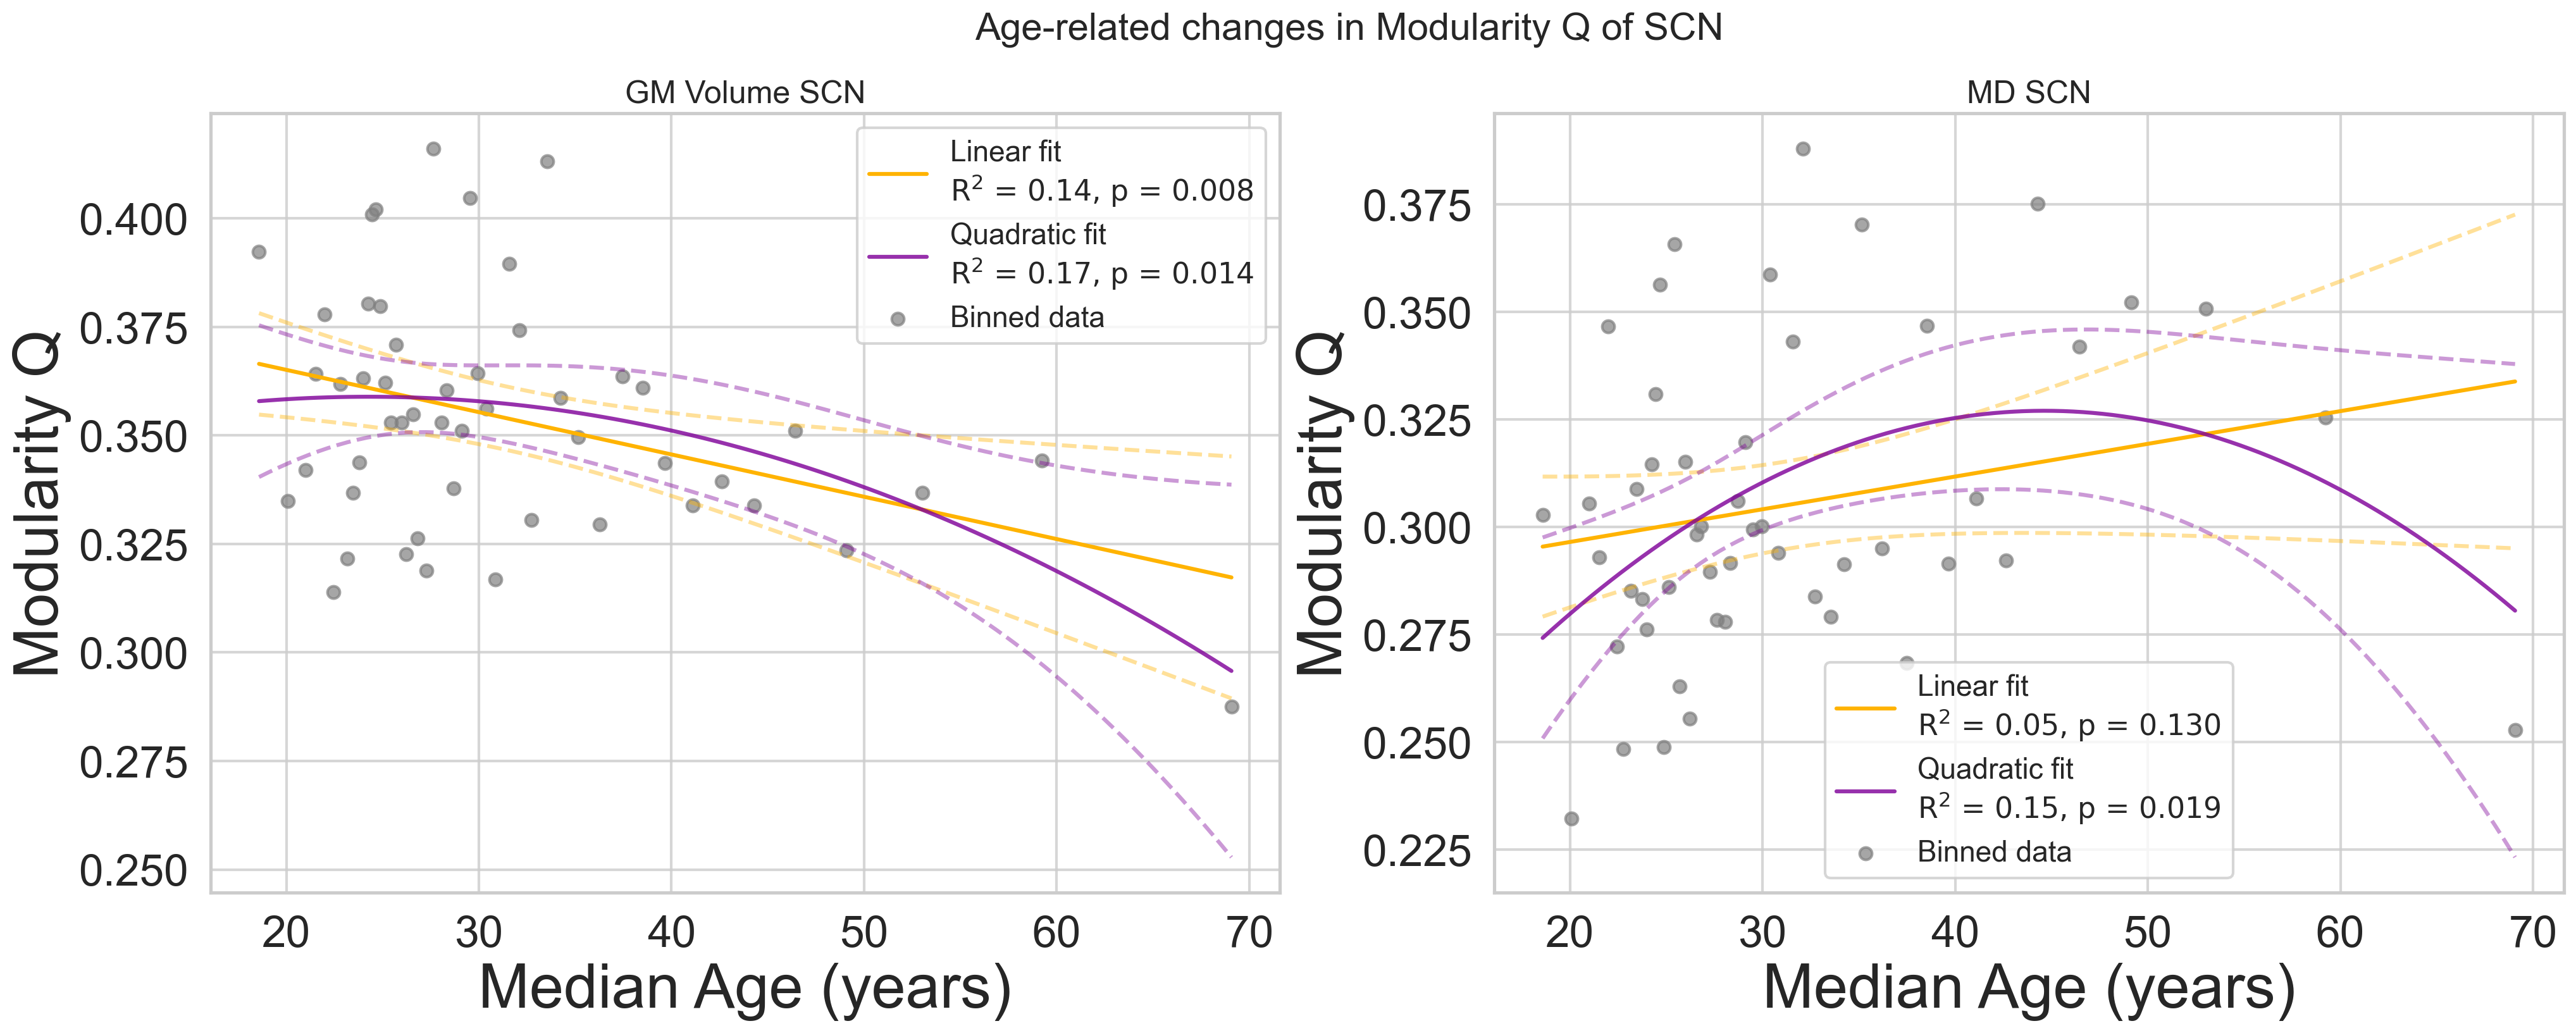

In [85]:
import statsmodels.formula.api as smf


VALUE_VIS = {
    "global_efficiency": "Global Efficiency",
    "modularity_Q": "Modularity Q",
    "strength_mean": "Mean Nodal Strength",
}

METRIC_VIS = {
    "gm_vol": "GM Volume",
    "adc": "MD",
}

val = "modularity_Q"
use_weights = False

fig, axes = plt.subplots(1, len(metrics), figsize=(12 * len(metrics), 8), squeeze=False)

for ax, metric in zip(axes.flatten(), metrics):
    out = result[metric]

    d = out["metrics"].drop_duplicates("age_median",keep="first")
    d["modularity_Q"] = d[[f"modularity_Q_{rep}" for rep in range(metrics_cfg.louvain_repeats)]].mean(axis=1)
    d["modularity_Q_std"] = d[[f"modularity_Q_{rep}" for rep in range(metrics_cfg.louvain_repeats)]].std(axis=1)
    d["modularity_Q_norm"] = d["modularity_Q"] / d["modularity_Q_std"]

    if use_weights:
        d["weight"], _ = compute_poststrat_weights(
            d,
            israel_population,
            age_col="age_median",
            cap=None,  # try None first; if still spiky, use 4 or 5
            return_bin_table=True,
        )
    else:
        d["weight"] = 1.0


    
    m_lin = smf.wls(f"{val} ~ age_median", data=d, weights=d["weight"]).fit()
    m_quad = smf.wls(f"{val} ~ age_median + I(age_median**2)", data=d, weights=d["weight"]).fit()

    age_range = np.linspace(d["age_median"].min(), d["age_median"].max(), 100)
    # pred_lin = m_lin.predict(pd.DataFrame({"age_median": age_range}))
    pred_lin = m_lin.get_prediction(pd.DataFrame({"age_median": age_range})).summary_frame()
    # pred_quad = m_quad.predict(pd.DataFrame({"age_median": age_range})) 
    pred_quad = m_quad.get_prediction(pd.DataFrame({"age_median": age_range})).summary_frame()
    ax.plot(age_range, pred_lin["mean"], label="Linear fit\n" + f"$R^2$ = {m_lin.rsquared:.2f}, p = {m_lin.f_pvalue:.3f}", color=COL_RAW)
    ax.plot(age_range, pred_lin["mean_ci_lower"], color=COL_RAW, alpha=0.4, linestyle="--")
    ax.plot(age_range, pred_lin["mean_ci_upper"], color=COL_RAW, alpha=0.4, linestyle="--")
    # ax.fill_between(
    #     age_range,
    #     pred_lin["mean_ci_lower"],
    #     pred_lin["mean_ci_upper"],
    #     color=COL_RAW,
    #     alpha=0.2,
    # )
    ax.plot(age_range, pred_quad["mean"], label="Quadratic fit\n"+f"$R^2$ = {m_quad.rsquared:.2f}, p = {m_quad.f_pvalue:.3f}", color=COL_WEIGHTED)
    ax.plot(age_range, pred_quad["mean_ci_lower"], color=COL_WEIGHTED, alpha=0.4, linestyle="--")
    ax.plot(age_range, pred_quad["mean_ci_upper"], color=COL_WEIGHTED, alpha=0.4, linestyle="--")
    # ax.fill_between(
    #     age_range,
    #     pred_quad["mean_ci_lower"],
    #     pred_quad["mean_ci_upper"],
    #     color=COL_WEIGHTED,
    #     alpha=0.2,
    # )
    ax.scatter(
        d["age_median"],
        d[val],
        label="Binned data",
        color="gray",
        alpha=0.7,
        s=50,
    )

    ax.set_xlabel("Median Age (years)")
    ax.set_ylabel(VALUE_VIS[val])
    ax.set_title(f"{METRIC_VIS[metric]} SCN")
    ax.legend()
plt.suptitle(f"Age-related changes in {VALUE_VIS[val]} of SCN")

In [45]:
import statsmodels.formula.api as smf
from statsmodels.stats import multitest

VALUE_VIS = {
    "global_efficiency": "Global Efficiency",
    "modularity_Q": "Modularity Q",
    "strength_mean": "Mean Nodal Strength",
}

METRIC_VIS = {
    "gm_vol": "GM Volume",
    "adc": "MD",
}

network_measure = "strength"
use_weights = False

# fig, axes = plt.subplots(1, len(metrics), figsize=(12 * len(metrics), 8), squeeze=False)

roi_stats = {}

for metric in metrics:
    out = result[metric]
    df = out["metrics"].copy()
    stats = parcels.copy()
    for i, row in parcels.iterrows():
        roi = row["index"]
        d = df[df["index"] == roi]
        if use_weights:
            d["weight"], _ = compute_poststrat_weights(
                d,
                israel_population,
                age_col="age_median",
                cap=None,  # try None first; if still spiky, use 4 or 5
                return_bin_table=True,
            )
        else:
            d["weight"] = 1.0
        m_lin = smf.wls(f"{network_measure} ~ age_median", data=d, weights=d["weight"]).fit()
        m_quad = smf.wls(f"{network_measure} ~ age_median + I(age_median**2)", data=d, weights=d["weight"]).fit()
        # do f test and extract stats
        f,p,_ = m_quad.compare_f_test(m_lin)
        stats.at[i, "f_quad_vs_linear_adj"] = f
        stats.at[i, "pval_quad_vs_linear_adj"] = p
        for m, m_name in zip([m_lin, m_quad], ["lin", "quad"]):
            stats.at[i, f"{m_name}_rsq"] = m.rsquared
            stats.at[i, f"{m_name}_rsq_adj"] = m.rsquared_adj
            stats.at[i, f"{m_name}_pvalue"] = m.f_pvalue
            stats.at[i, f"{m_name}_beta_age"] = m.params.get("age_median", np.nan)
            stats.at[i, f"{m_name}_pvalue_age"] = m.pvalues.get("age_median", np.nan)
            if m_name == "quad":
                stats.at[i, f"{m_name}_beta_age_sq"] = m.params.get("I(age_median ** 2)", np.nan)
                stats.at[i, f"{m_name}_pvalue_age_sq"] = m.pvalues.get("I(age_median ** 2)", np.nan)
    # FDR correction for multiple comparisons (ROIs)
    for m_name in ["lin", "quad"]:
        for term in ["", "_age", "_age_sq"]:
            pcol = f"{m_name}_pvalue{term}"
            if pcol not in stats.columns:
                continue
            pvals = stats[f"{m_name}_pvalue{term}"].values
            reject, pvals_fdr, _, _ = multitest.multipletests(pvals, alpha=0.05, method="fdr_bh")
            stats[f"{m_name}_pvalue{term}_fdr"] = pvals_fdr
            stats[f"{m_name}_significant{term}_fdr"] = reject
    # do the same for the quadratic vs linear F-test
    f_pvals = stats["pval_quad_vs_linear_adj"].values
    reject, pvals_fdr, _, _ = multitest.multipletests(f_pvals, alpha=0.05, method="fdr_bh")
    stats["pval_quad_vs_linear_adj_fdr"] = pvals_fdr
    stats["significant_quad_vs_linear_fdr"] = reject
    roi_stats[metric] = stats

    #     break
    # break

/tmp/ipykernel_15455/3857975836.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d["weight"] = 1.0
/tmp/ipykernel_15455/3857975836.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d["weight"] = 1.0
/tmp/ipykernel_15455/3857975836.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-

<Axes: >

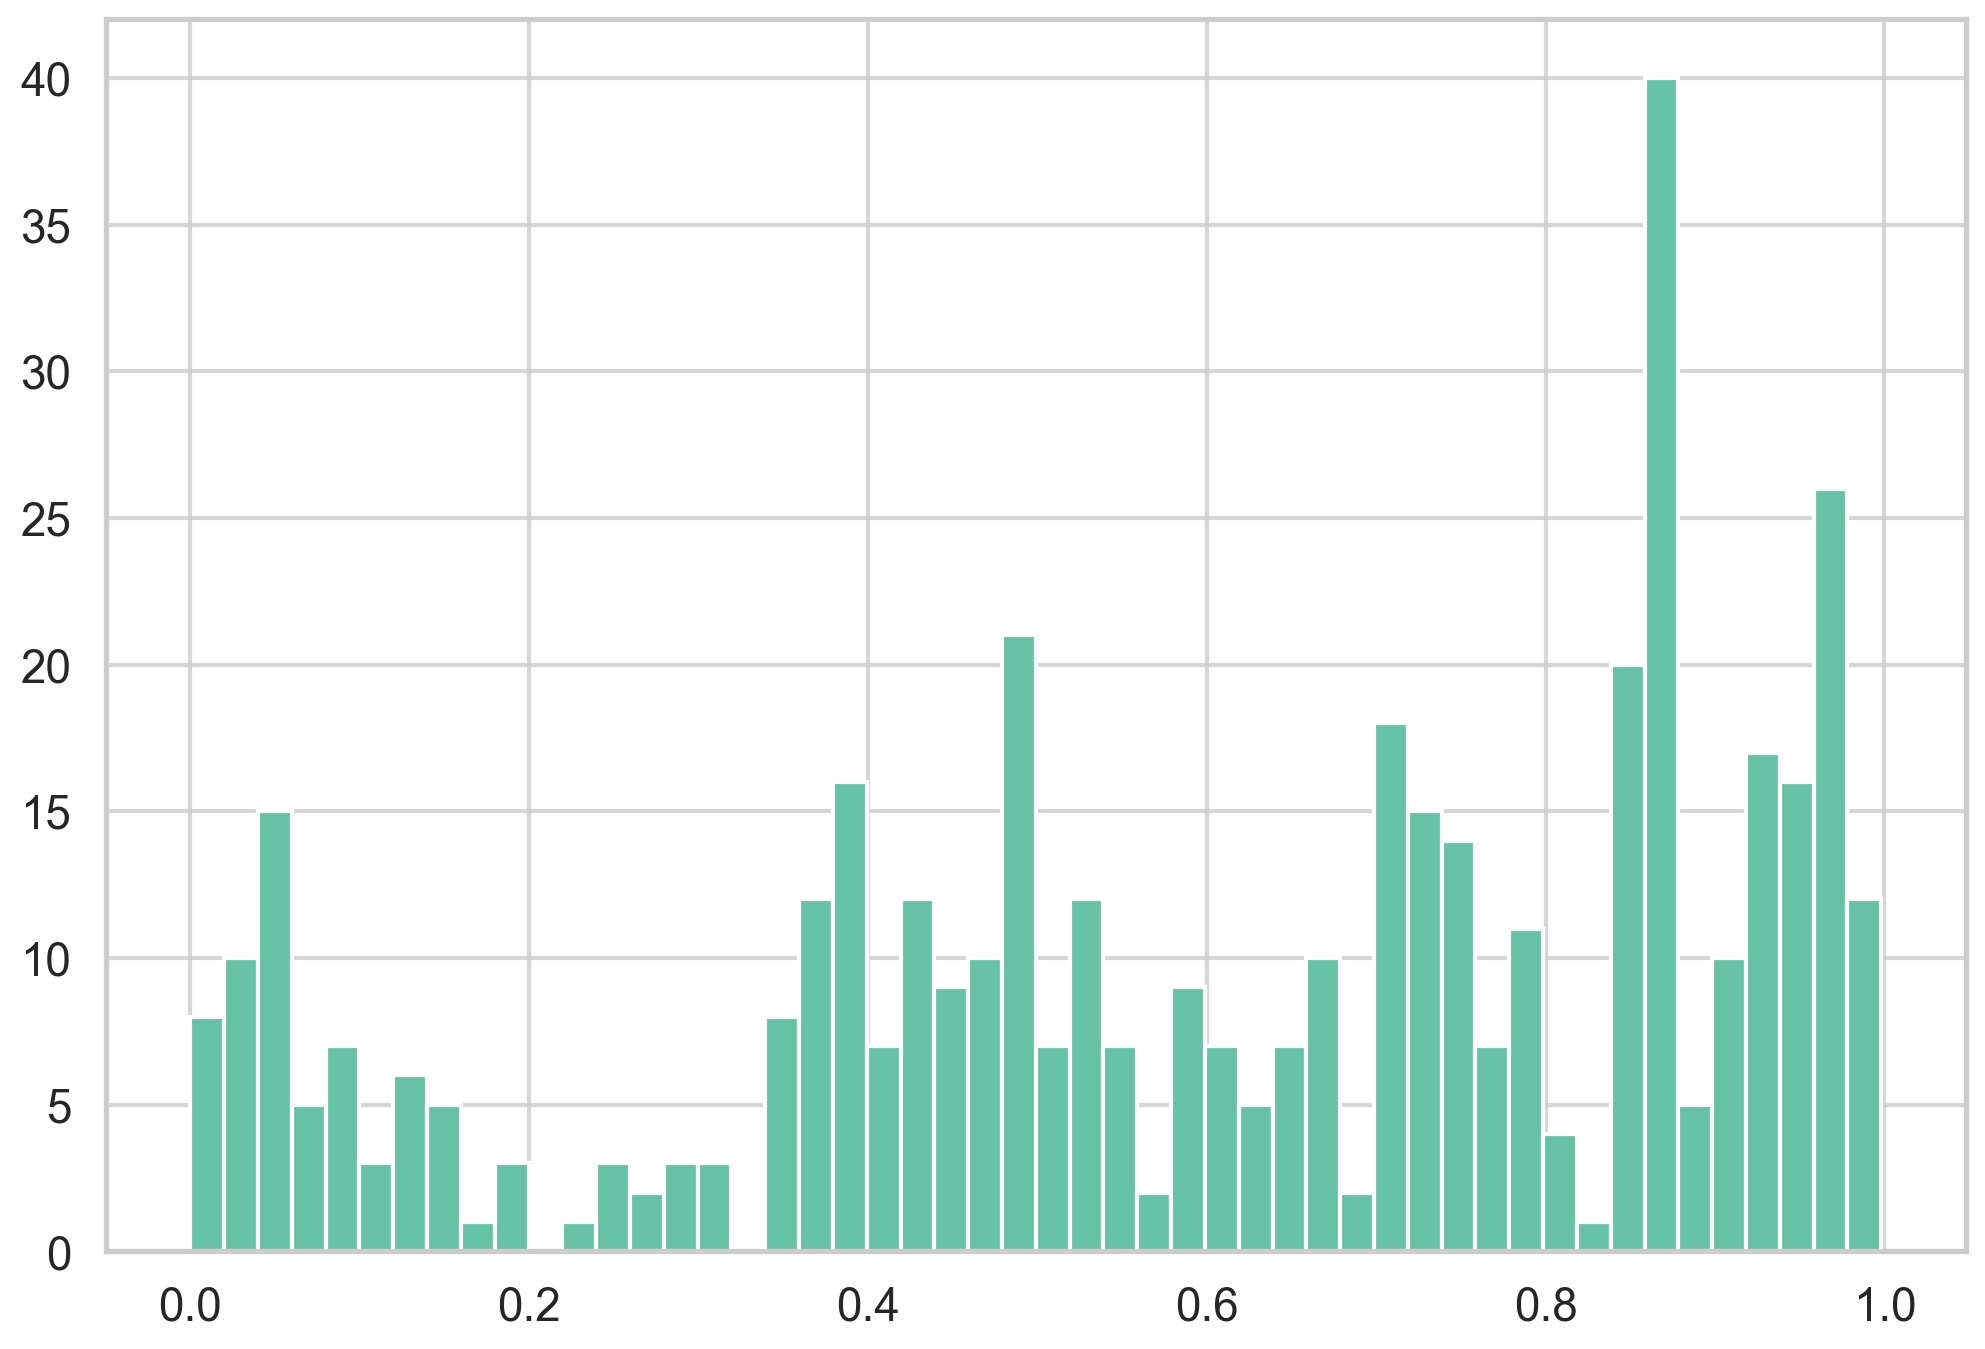

In [18]:
stats = roi_stats["gm_vol"]

stats["lin_pvalue_fdr"].hist(bins=50)

In [21]:
OUTPUT_DIR

PosixPath('/media/storage/phd/neuroaging/figures/fig5/schaefer2018tian2020_400_7')

In [79]:
import numpy as np
import pandas as pd
import nibabel as nb
from nilearn import surface, datasets
from surfplot import Plot
from matplotlib.colors import TwoSlopeNorm  # nice diverging colours
from neuromaps.datasets import fetch_fslr
from brainspace.datasets import load_parcellation

metric = "gm_vol"
m_name = "quad"
term = ""

p_col = f"{m_name}_pvalue{term}_fdr"
val_col = f"{m_name}_rsq"

vis_dir = OUTPUT_DIR / metric / network_measure / m_name
vis_dir.mkdir(parents=True, exist_ok=True)

atlas_img = nib.load(nifti_matlab)

# ---------------------------------------------------------------------
# 2.  FETCH A STANDARD SURFACE  (fsaverage5 = 10k vertices per hemi)
# ---------------------------------------------------------------------
surfaces = fetch_fslr()
lh, rh = surfaces["inflated"]


# ---------------------------------------------------------------------
# 3.  SAMPLE ATLAS VOXELS → SURFACE  (nearest-neighbour so labels stay int)
# ---------------------------------------------------------------------
# add schaefer parcellation (no color bar needed)
lh_parc, rh_parc = load_parcellation("schaefer")
# ---------------------------------------------------------------------
# 4.  MAP REGION IDs → METRIC VALUES
#     vertices with label 0 (background) → NaN so they render transparent
# ---------------------------------------------------------------------

value_map = {}
value_map_subcortex = {"region": [], "value": [], "Hemisphere": []}

vis_df = roi_stats[metric].copy()

value_map_lh = {}  # New: separate map for left hemisphere
value_map_rh = {}  # New: separate map for right hemisphere


for i, row in vis_df.iterrows():
    label = row[region_col]
    hemi_row = row["hemisphere"]  # Get hemisphere from your DataFrame row

    # Apply thresholds
    value = np.nan if row[p_col] > 0.05 else row[val_col]

    # value = float(vis_df.loc[i, "color_tag"]) + 1

    # Populate the correct hemisphere's value_map
    # Assuming your labels are global and you use the 'hemisphere' column to distinguish
    # If your Schaefer labels are already separated by hemi (e.g., 1-200 for LH, 201-400 for RH)
    # then you might only need to check the label range and not the 'hemisphere' column.
    # For Schaefer, the labels usually run 1-N for LH and N+1 - 2N for RH
    if "schaefer" in ATLAS:
        if label > int(ATLAS.split("_")[1]):
            value_map_subcortex["region"].append(label)
            value_map_subcortex["value"].append(value)
            value_map_subcortex["Hemisphere"].append(row["hemisphere"])
        else:
            if hemi_row == "L":
                value_map_lh[label] = value
            elif hemi_row == "R":
                value_map_rh[label] = value
        # Subcortex handling would go here if you were preparing for separate subcortical visualization
        # else: # This implies it's subcortical or other non-surface region
        #     value_map_subcortex["region"].append(label)
        #     value_map_subcortex["value"].append(value)
        #     value_map_subcortex["Hemisphere"].append(row["hemisphere"])

# Vectorize mapping for left and right hemispheres separately
vec_lh = np.vectorize(lambda x: value_map_lh.get(x, np.nan))
data_lh_mapped = vec_lh(lh_parc)  # Apply LH map to LH parcellation
vec_rh = np.vectorize(lambda x: value_map_rh.get(x, np.nan))
data_rh_mapped = vec_rh(rh_parc)  # Apply RH map to RH parcellation

<Axes: >

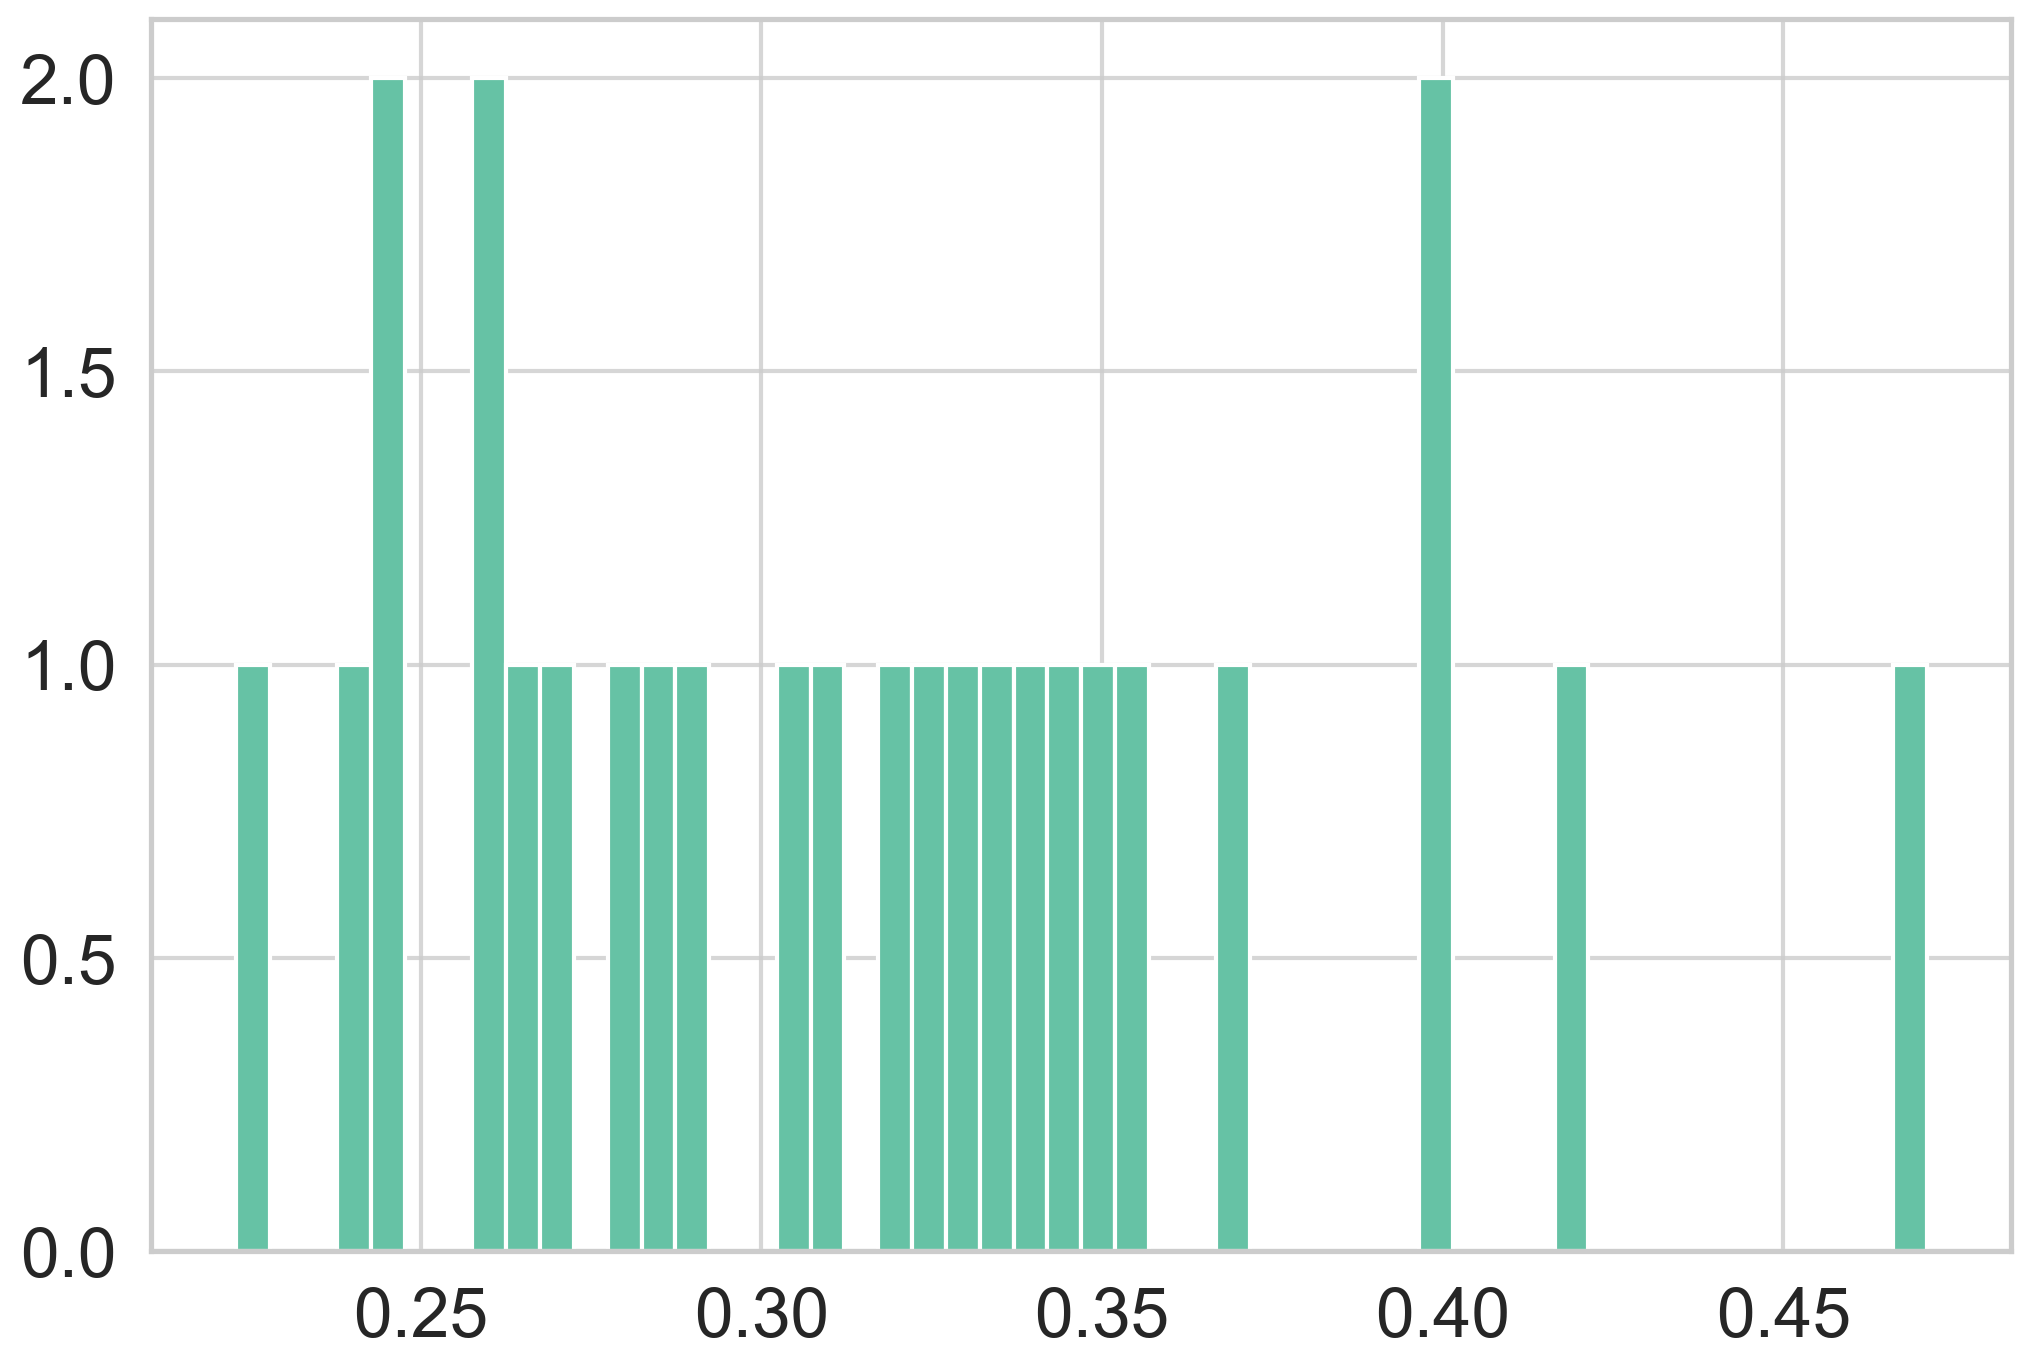

In [80]:
vis_df[vis_df[p_col] < 0.05][val_col].hist(bins=50)

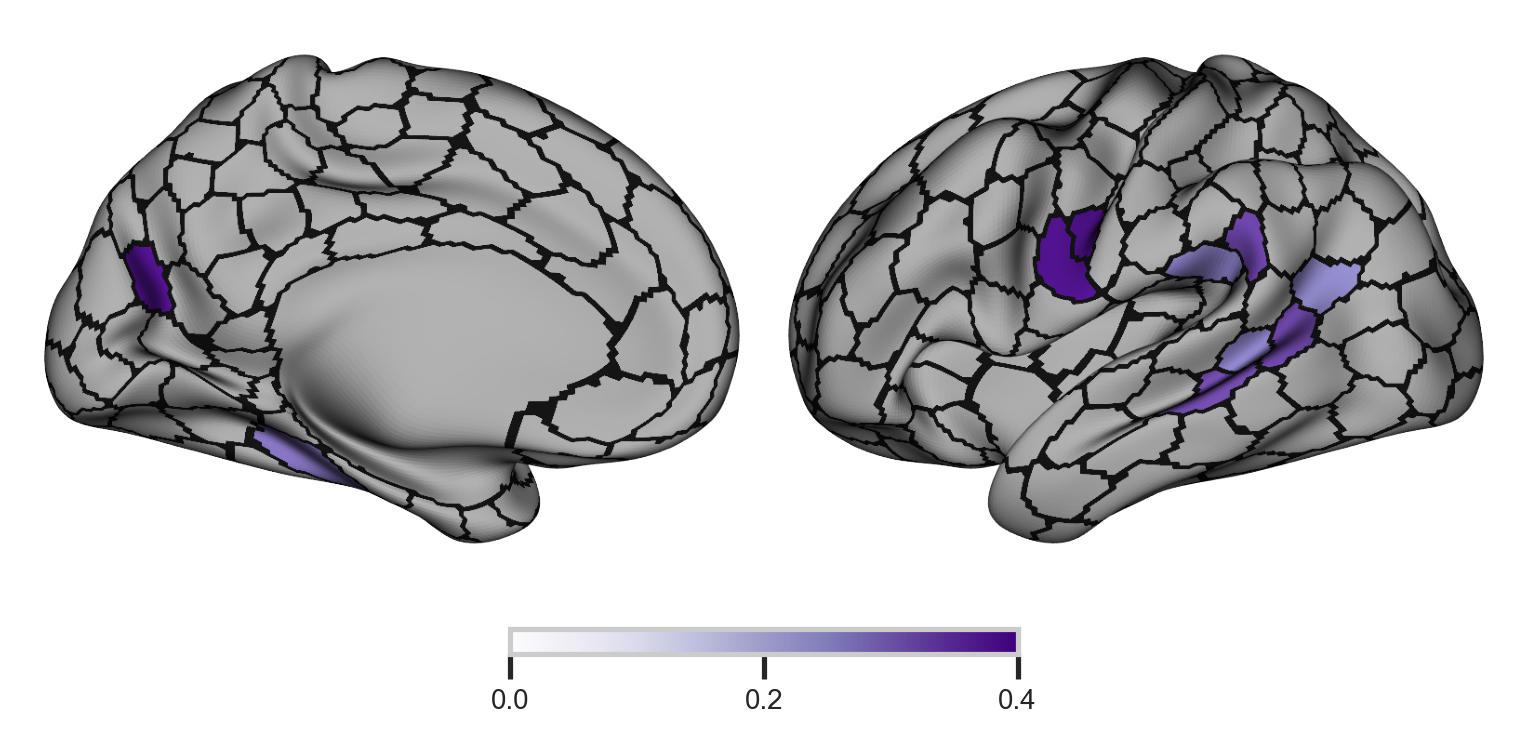

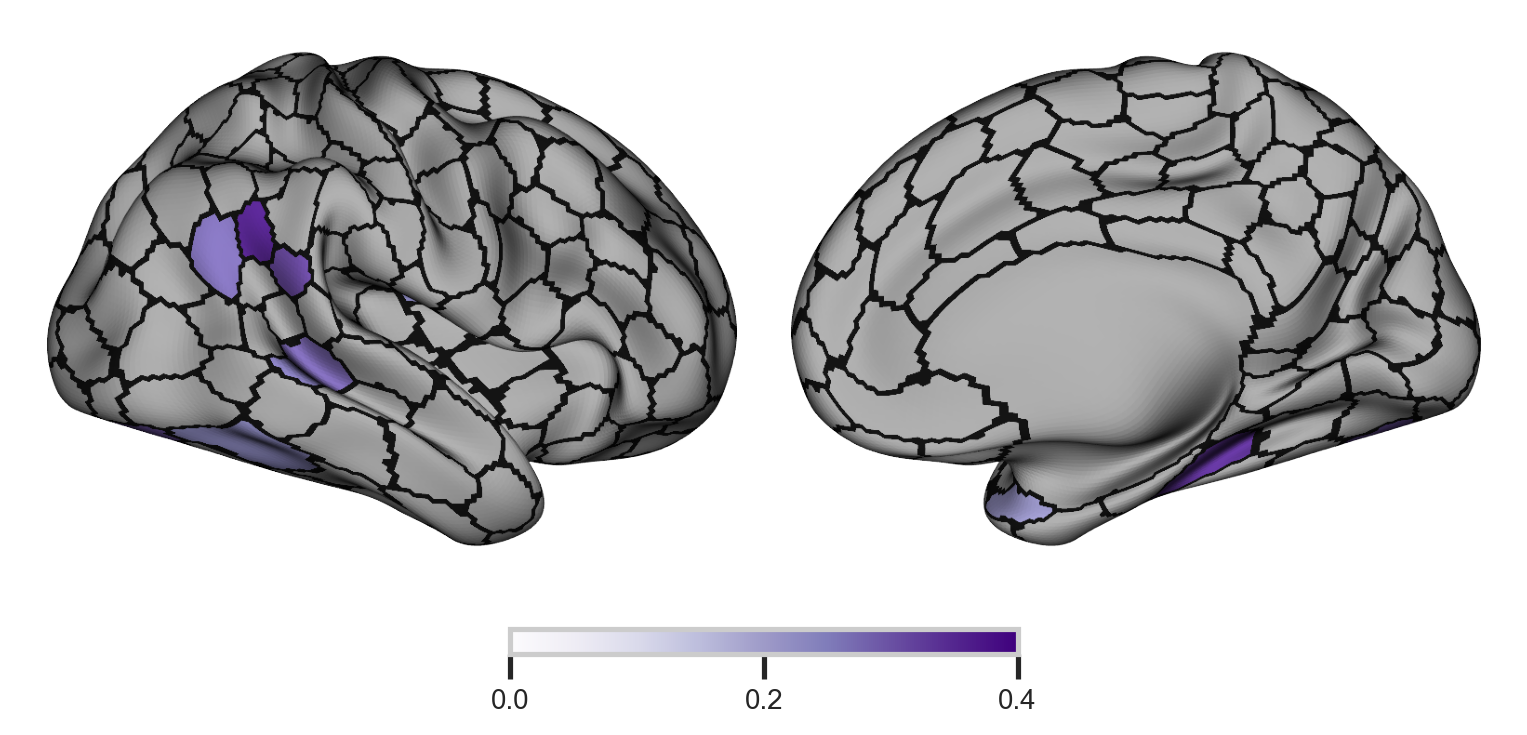

In [81]:
vmin = 0
vmax = 0.4


# Corrected loop for plotting each hemisphere independently
for hemi_key, hemi_surf_data, mapped_data, parcellation_data in zip(
    ["left", "right"],  # The key for surfplot's dictionary
    [lh, rh],  # The surface object for the current hemisphere
    [data_lh_mapped, data_rh_mapped],  # The mapped data for the current hemisphere
    [lh_parc, rh_parc],  # The parcellation for the current hemisphere
):
    # ---------------------------------------------------------------------
    # 5.  BUILD THE PLOT
    # ---------------------------------------------------------------------
    pref_surf = {
        "surf_lh": hemi_surf_data if hemi_key == "left" else None,
        "surf_rh": hemi_surf_data if hemi_key == "right" else None,
    }

    views = ["lateral", "medial"] if hemi_key == "right" else ["medial", "lateral"]

    p = Plot(
        **pref_surf,  # Unpack the surface dictionary
        views=views,  # Show both medial and lateral for this hemi
        size=(800, 300),  # px; change as needed
        zoom=1.6,
        layout="row",  # For a single hemisphere, row is fine
        mirror_views=False,  # Set to False, as we are plotting one hemi at a time
    )

    # ---- main data layer -------------------------------------------------
    # Pass only the data for the current hemisphere
    # The dictionary now contains only one key-value pair for the current hemisphere
    p.add_layer(
        {hemi_key: mapped_data},
        cmap="Purples",
        color_range=(vmin, vmax),  # Use symmetric range
        # norm=norm,  # Apply the symmetric normalization
        # cbar_label="network",
        cbar=True,  # Ensure colorbar is shown for each plot if desired, or handle globally
    )
    # ---- outline layer ---------------------------------------------------
    p.add_layer({hemi_key: parcellation_data}, cmap="gray", as_outline=True, cbar=False)

    fig = p.build(
        # cbar_kws=dict(location="bottom", decimals=2, shrink=0.6)
    )  # Added cbar_kws for better cbar display
    savefig_nice(
        fig,
        vis_dir / f"{hemi_key}_{metric}_{term}.png",
        tight=True,
        dpi=400,
    )

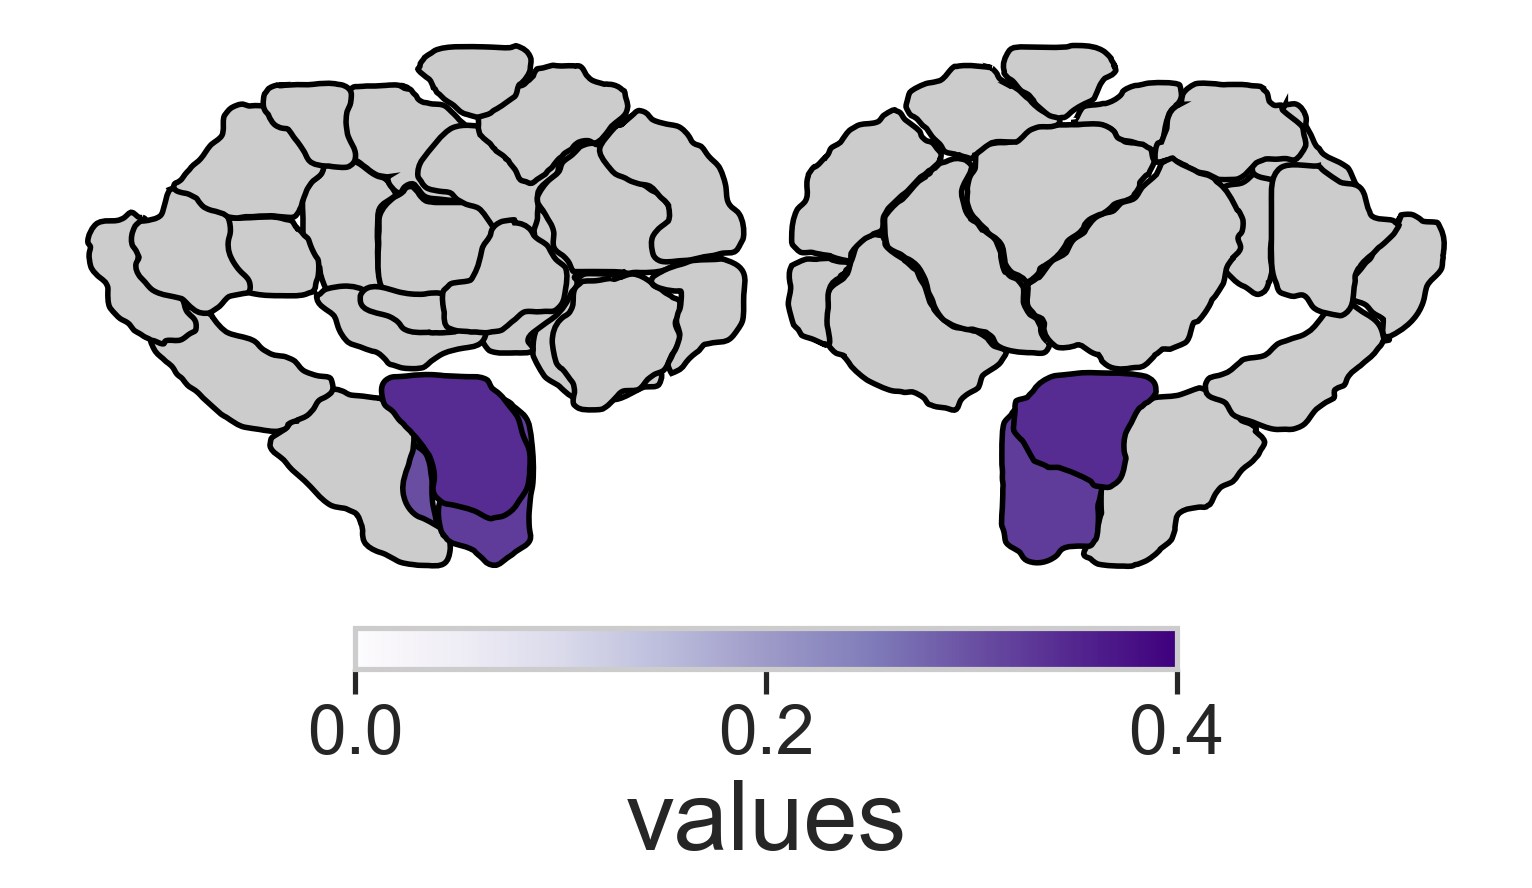

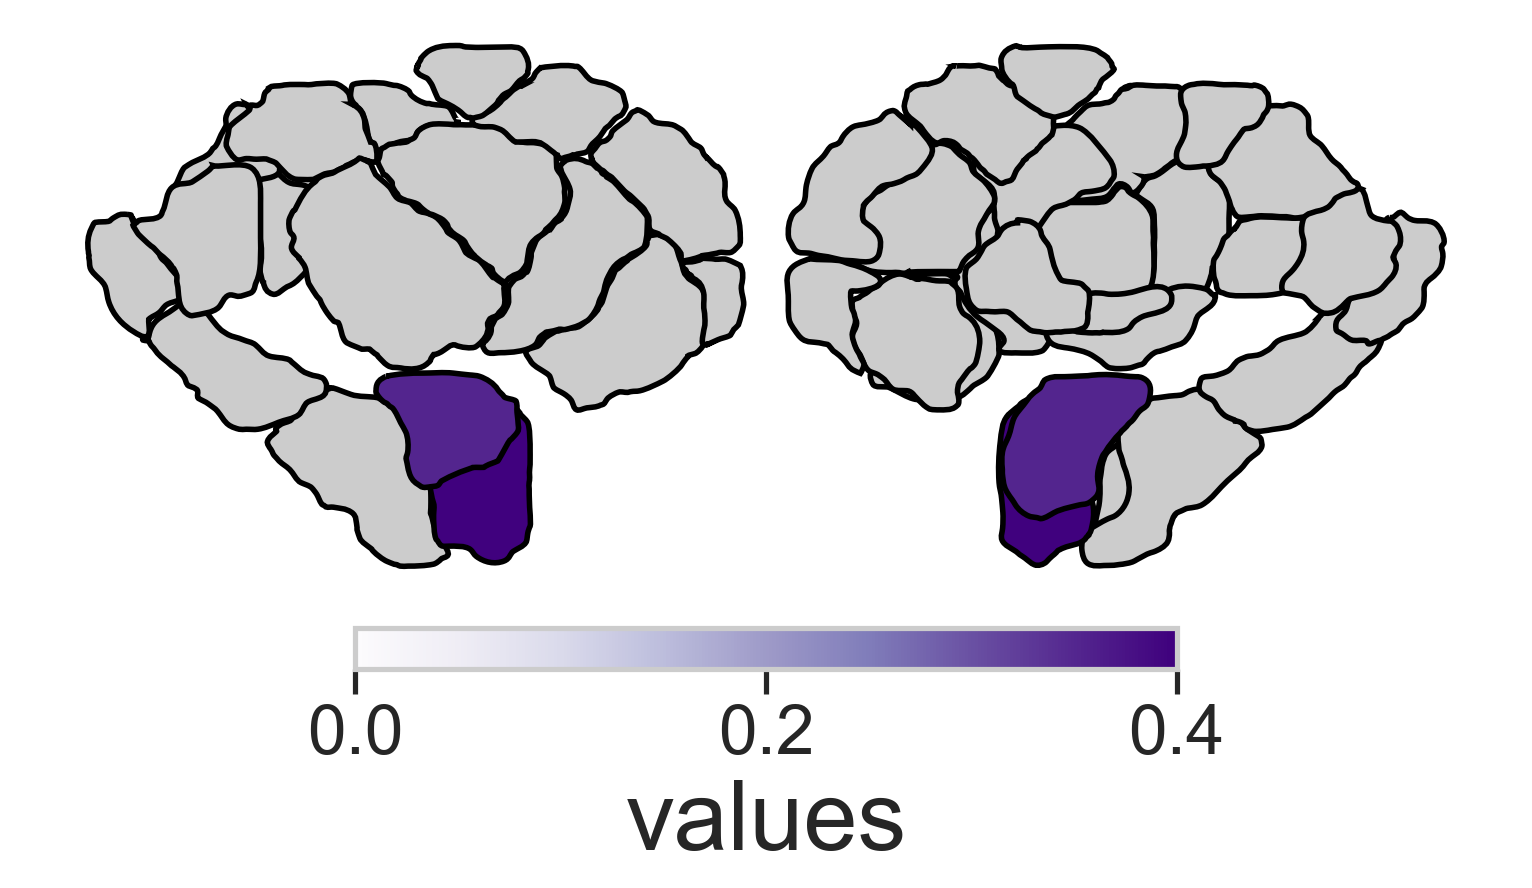

In [82]:
from subcortex_visualization.plotting import plot_subcortical_data

subcort_df = pd.DataFrame(value_map_subcortex)
if "schaefer" in ATLAS:
    subcort_df["region"] = subcort_df["region"] - int(ATLAS.split("_")[1])

# subcort_df["value"] = 6
for hemi in ["L", "R"]:

    fig = plot_subcortical_data(
        subcort_df,
        atlas="Melbourne_S3",
        show_legend=True,
        hemisphere=hemi,
        cmap="Purples",
        line_color="black",
        line_thickness=2,
        vmin=vmin,
        vmax=vmax,
        show_figure=False,
    )

    # save figure
    savefig_nice(
        fig,
        vis_dir / f"subcortical_{hemi}_{metric}_{term}.png",
        tight=True,
        dpi=400,
    )
    # savefig_nice(fig, OUTPUT_DIR / f"fig2_subcort_{metric}_{hemi}_{value_column}.png", dpi=400)

In [62]:
for metric in metrics:
    print("--- Significant ROIs for", metric, "---")
    sigs = roi_stats[metric].sort_values("quad_pvalue_fdr").head(5)
    for _, sig in sigs.iterrows():
        print(sig["index"], "--->", sig["name"], 
              f"(quad R²={sig['quad_rsq']:.3f}, p={sig['quad_pvalue_fdr']:.4f}, F-test p={sig['pval_quad_vs_linear_adj_fdr']:.4f})"
             )

--- Significant ROIs for gm_vol ---
26 ---> 7Networks_LH_Vis_26 (quad R²=0.471, p=0.0001, F-test p=0.3278)
43 ---> 7Networks_LH_SomMot_12 (quad R²=0.417, p=0.0007, F-test p=0.0043)
45 ---> 7Networks_LH_SomMot_14 (quad R²=0.399, p=0.0008, F-test p=0.0205)
421 ---> lAMY-rh (quad R²=0.397, p=0.0008, F-test p=0.9556)
365 ---> 7Networks_RH_Default_Par_4 (quad R²=0.371, p=0.0017, F-test p=0.5480)
--- Significant ROIs for adc ---
418 ---> CAU-DA-rh (quad R²=0.805, p=0.0000, F-test p=0.0000)
445 ---> CAU-DA-lh (quad R²=0.763, p=0.0000, F-test p=0.0000)
405 ---> HIP-head-l-rh (quad R²=0.757, p=0.0000, F-test p=0.0000)
446 ---> CAU-body-lh (quad R²=0.709, p=0.0000, F-test p=0.0001)
417 ---> CAU-VA-rh (quad R²=0.645, p=0.0000, F-test p=0.0001)


Plotting for Primary Visual (index 25)
Plotting for Primary Motor (index 42)
Plotting for Amygdala (index 420)


/tmp/ipykernel_15455/92524589.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_full["weight"], _ = compute_poststrat_weights(
/tmp/ipykernel_15455/92524589.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_full["weight"] = 1.0
/tmp/ipykernel_15455/92524589.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_

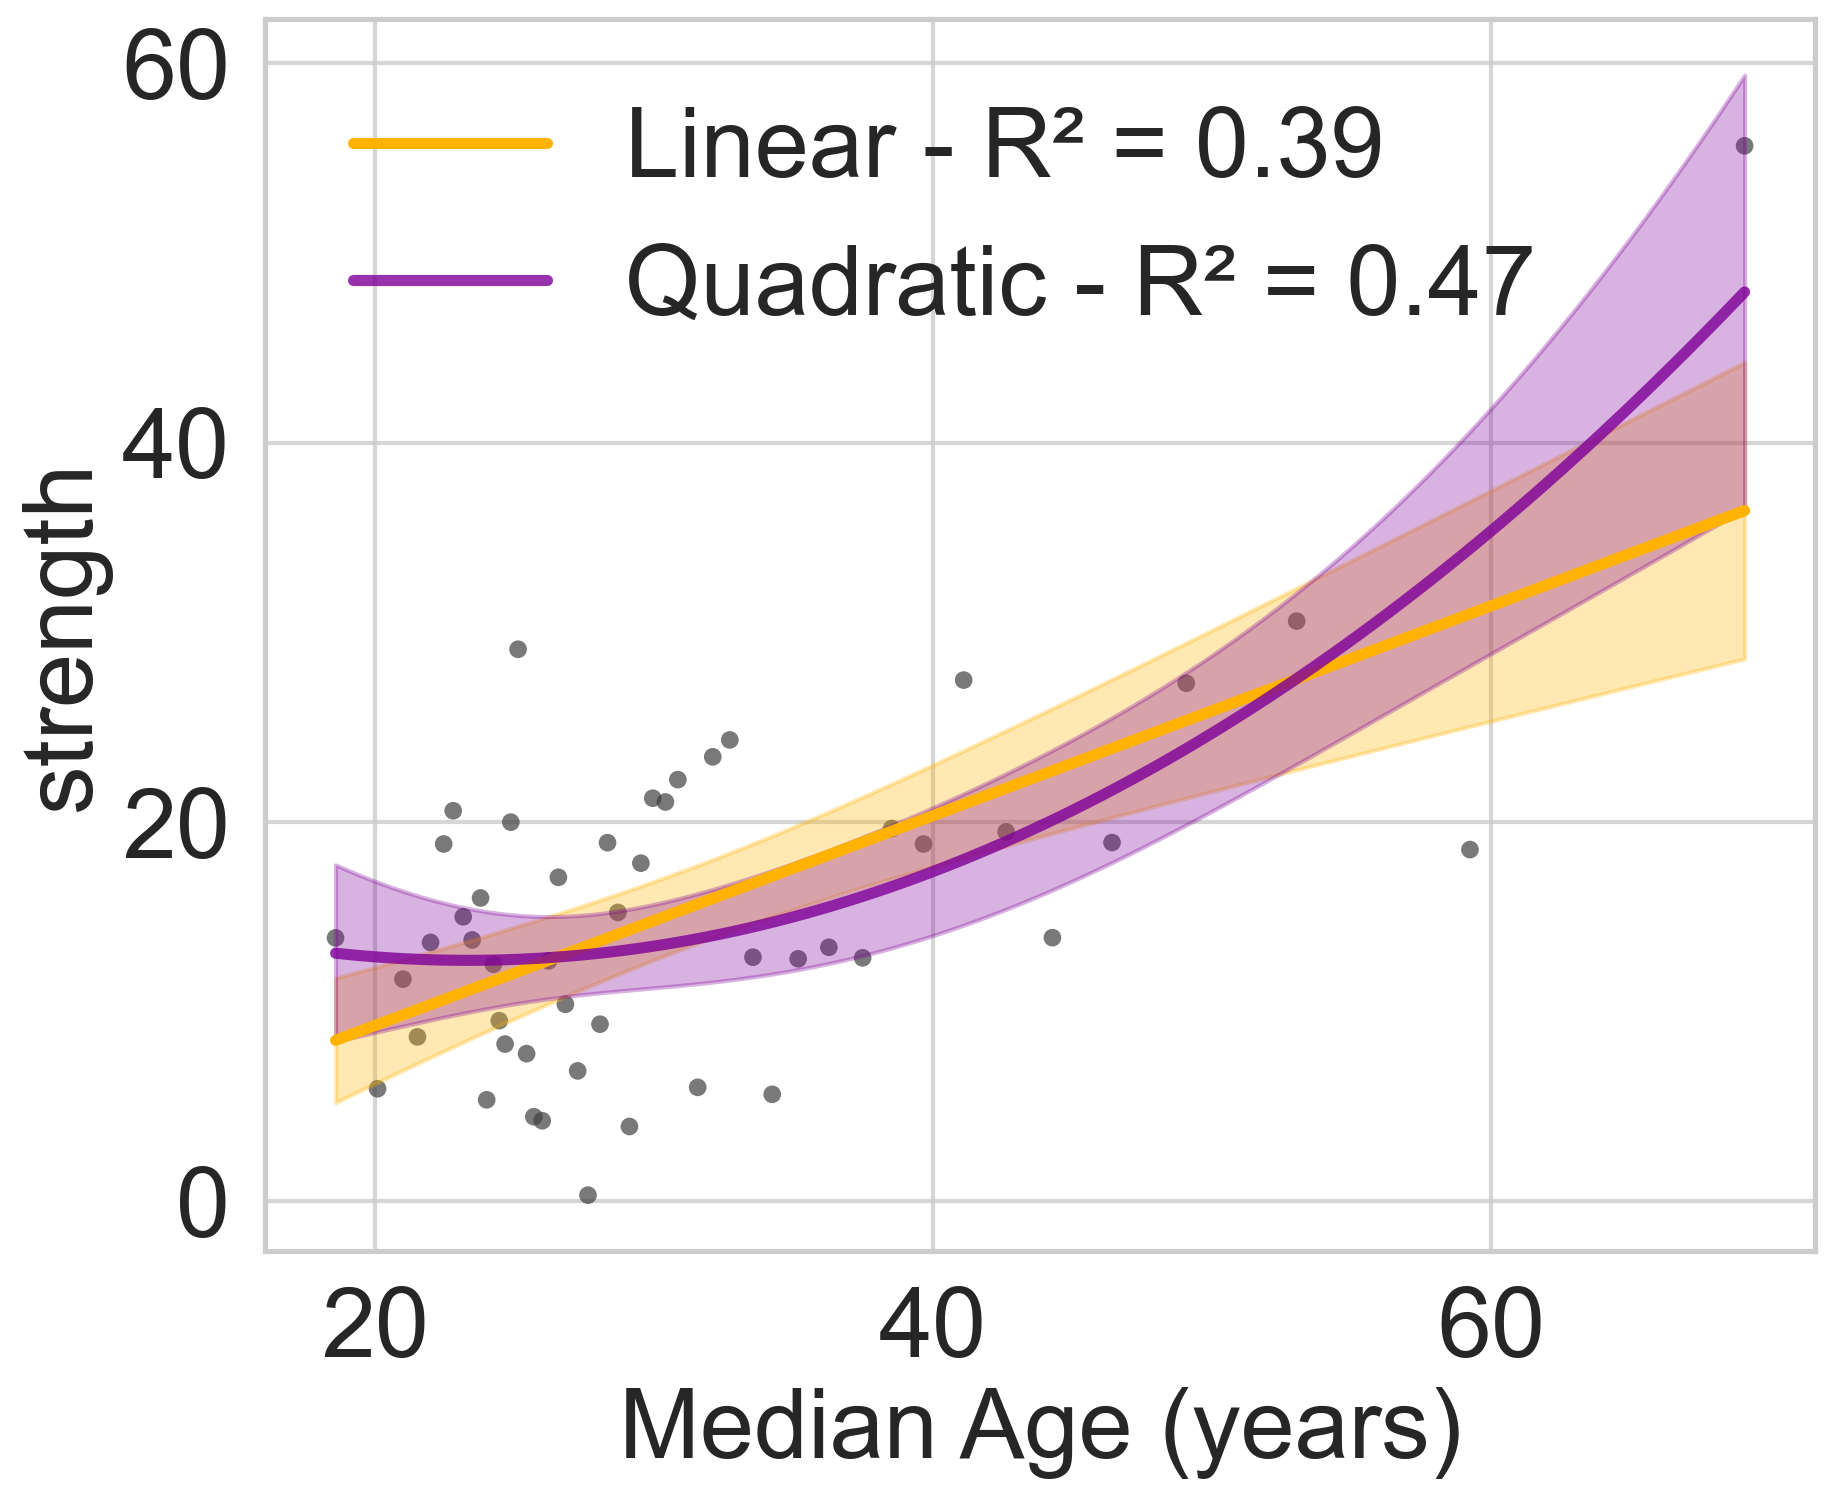

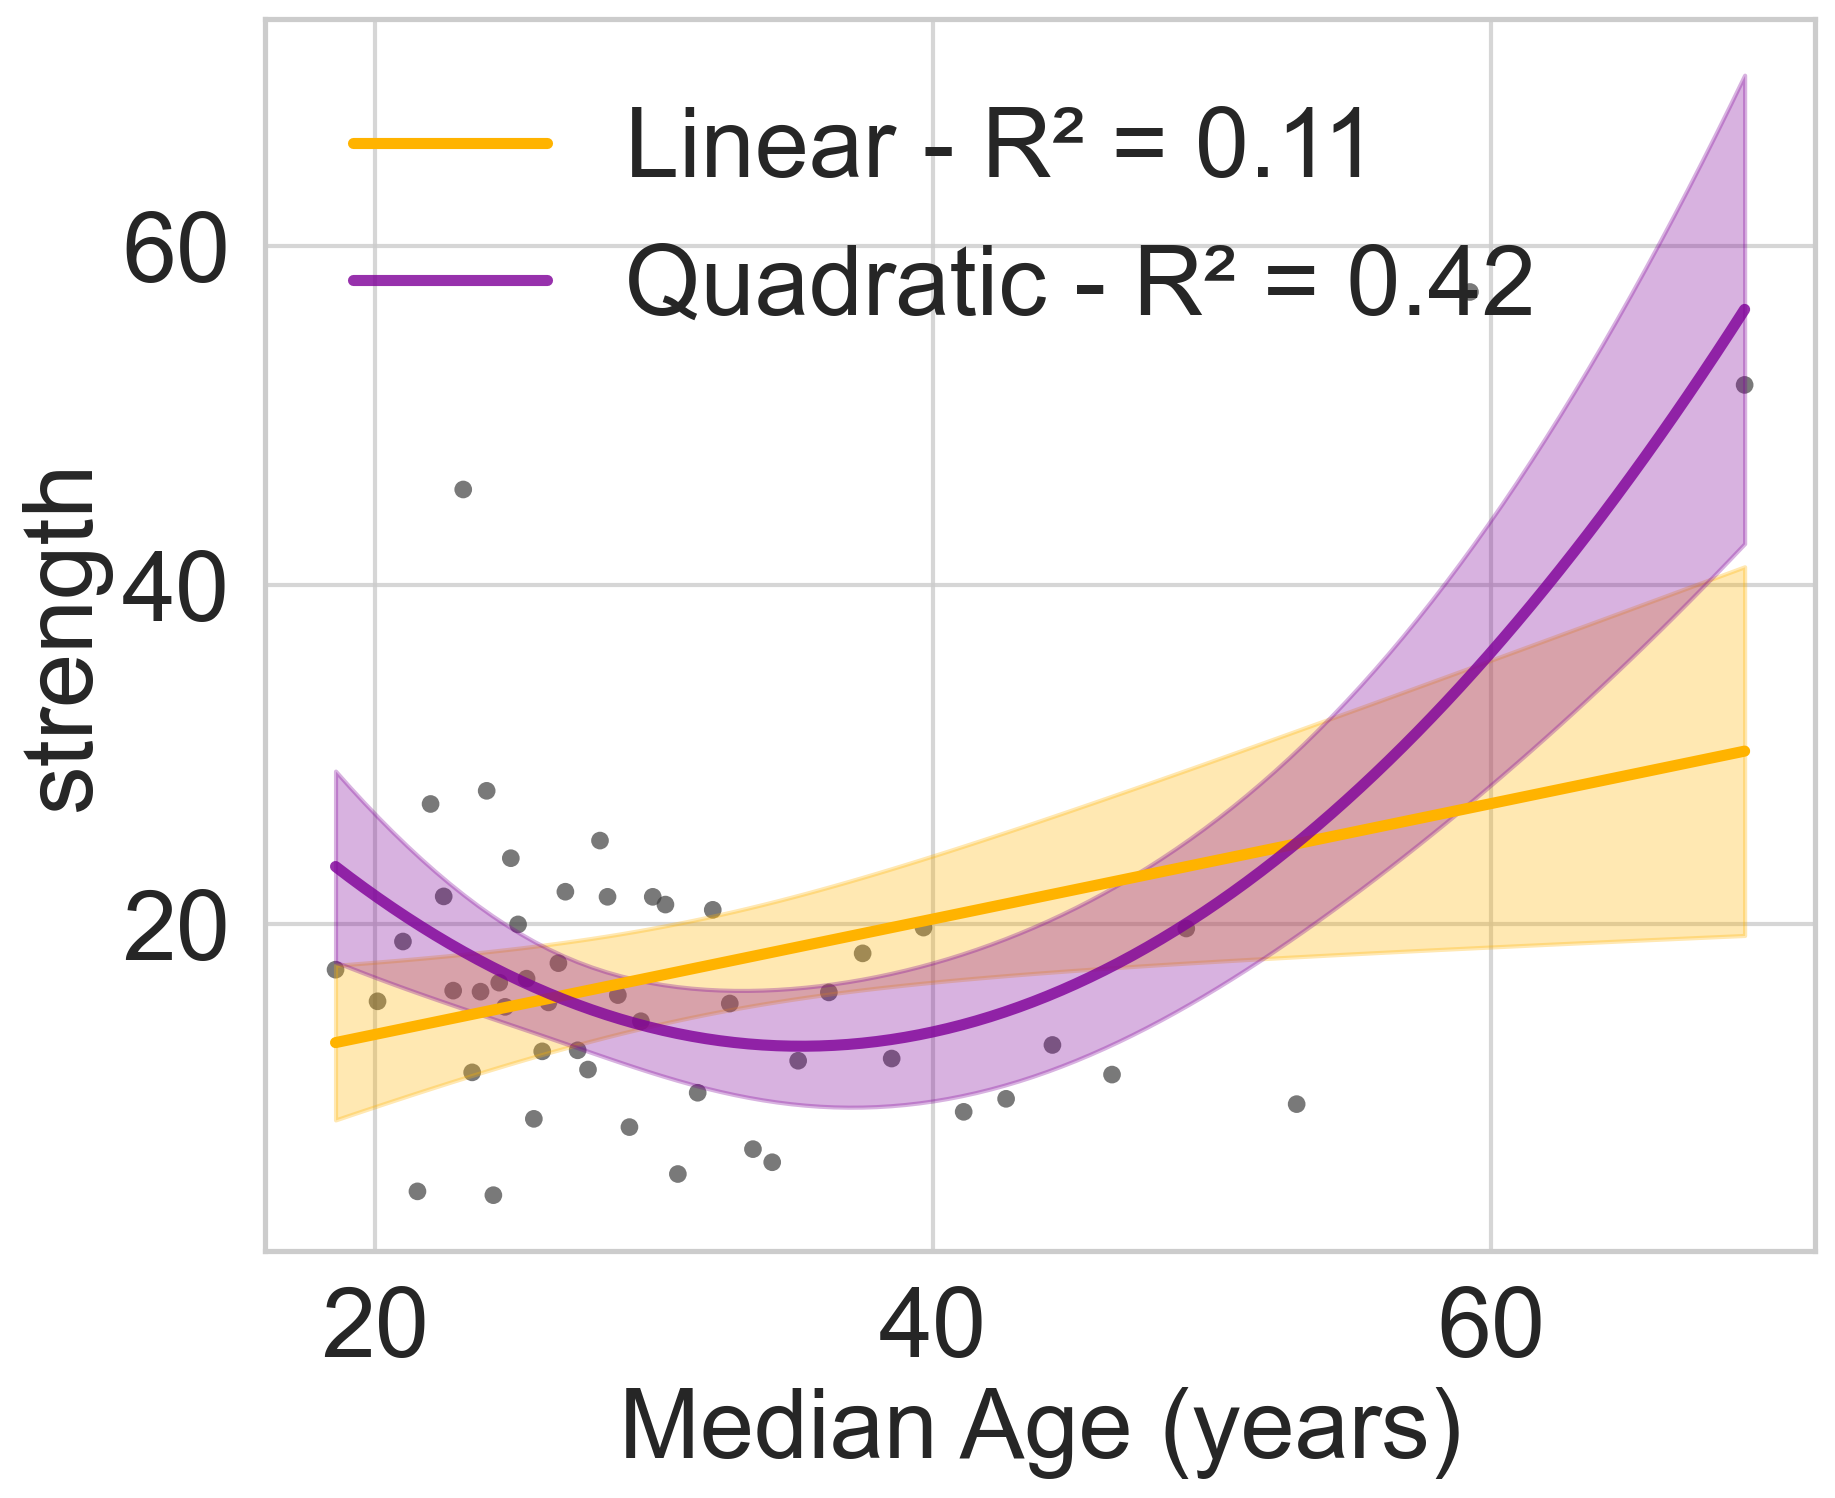

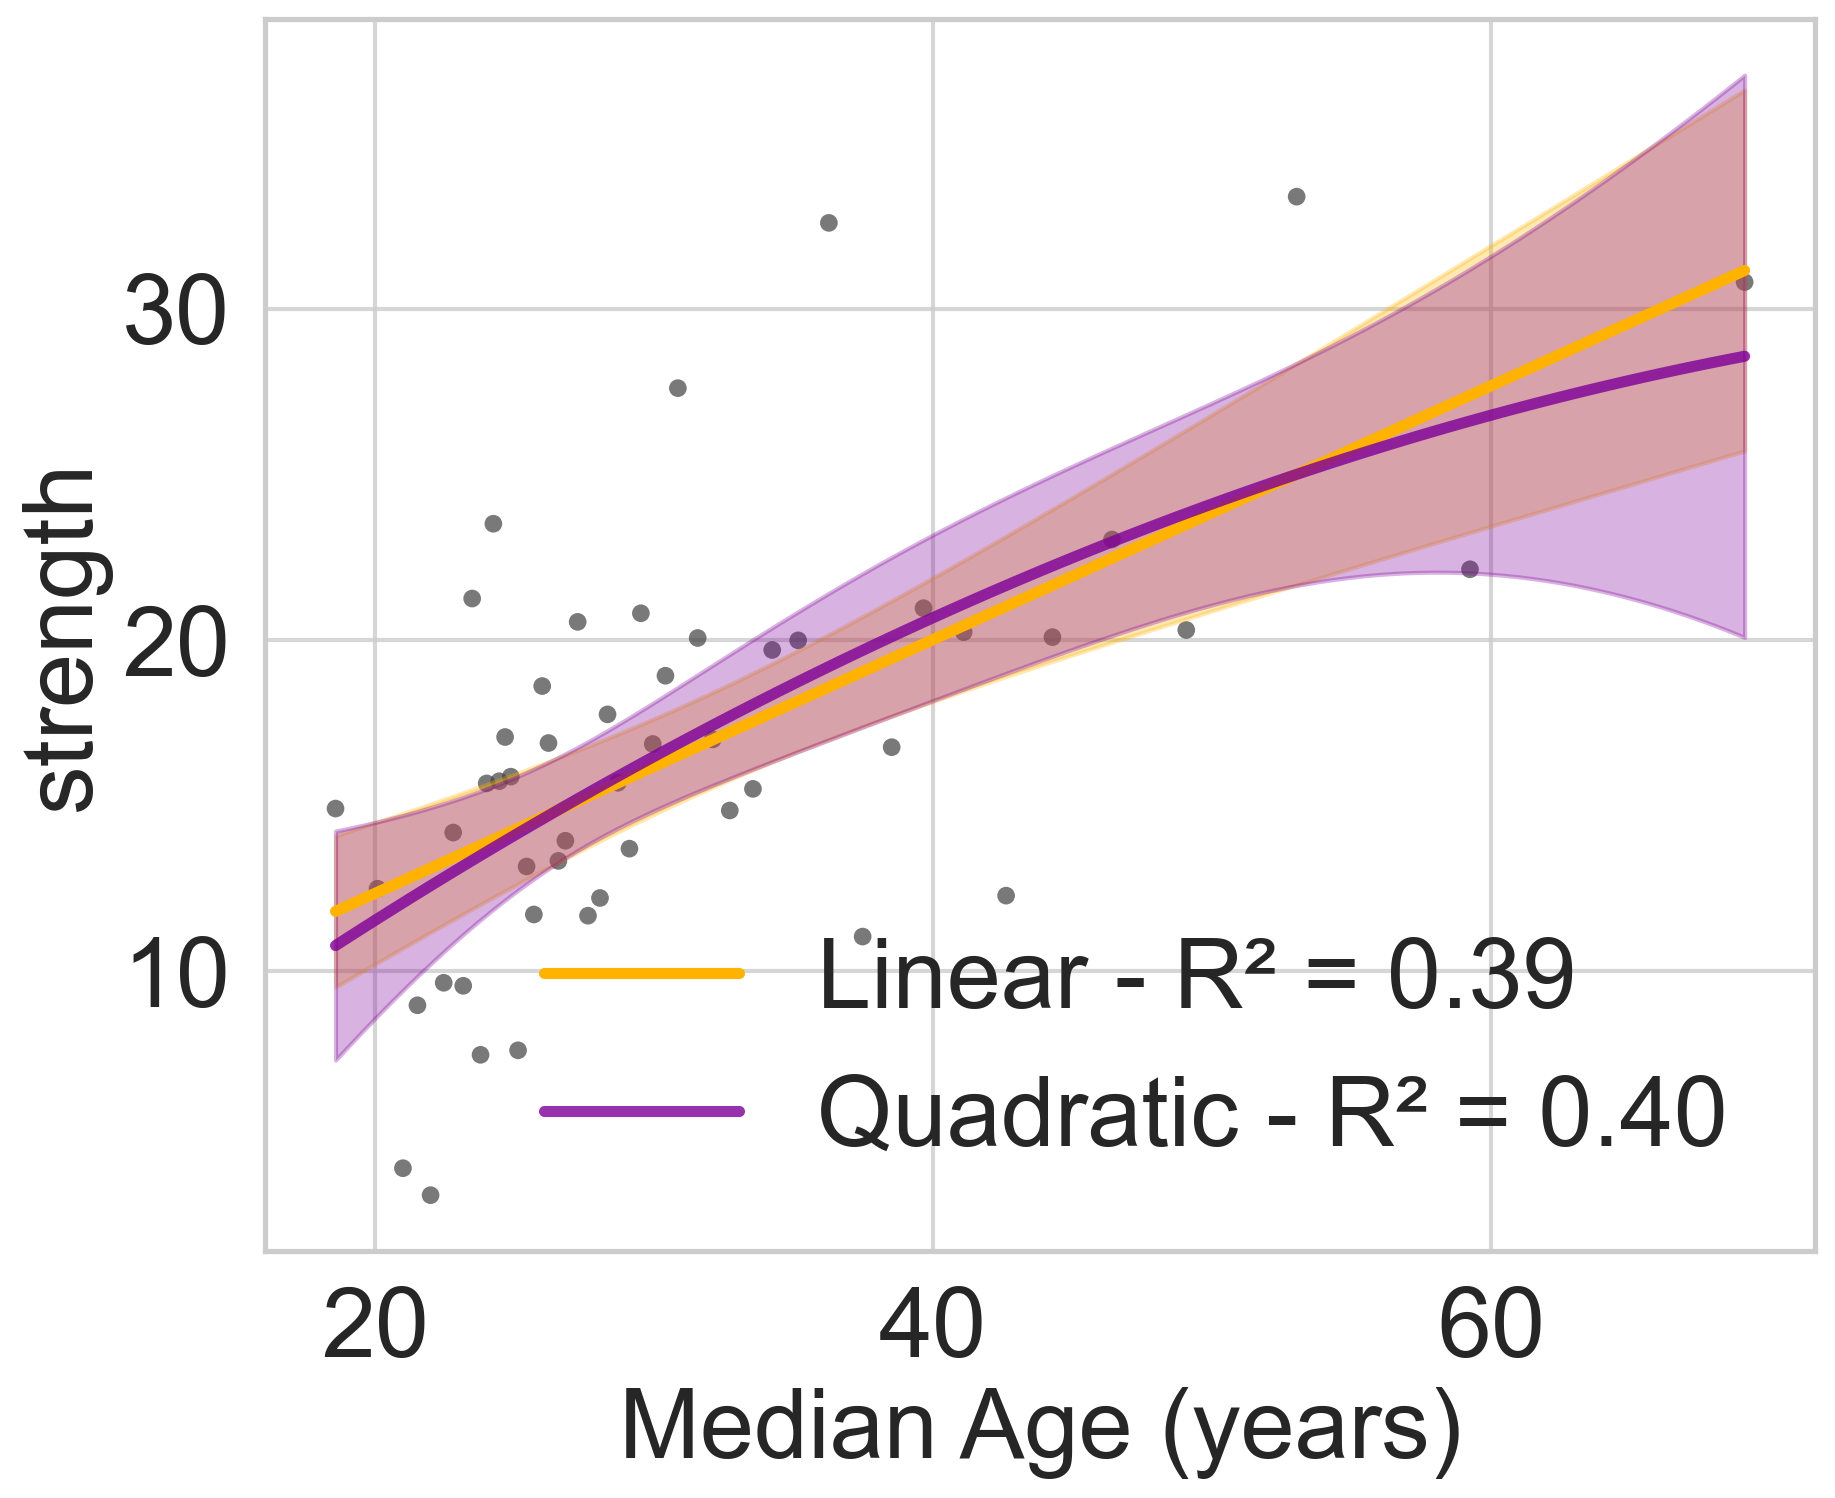

In [78]:
import seaborn as sns

orientation = {  # feel free to expand
    "gm_vol": "min",  # concave-down expected
    "adc": "max",  # concave-up expected
    # "fa"   : "min",
    # "rd"   : "min",
}

# adc_rois = {67: "precentral", 147: "SFG", 336: "MFG"}
adc_rois = {417: "Caudate", 404: "Hippocampus"}

# ROIS = {"gm_vol": {375: "VLPFC", 193: "precuneus"},"adc": {42: "precentral", 147: "SFG"}}
ROIS = {"gm_vol": {25: "Primary Visual", 42: "Primary Motor", 420:"Amygdala"}, "adc": adc_rois}

metric = "gm_vol"

use_weights = False
# i = vis_df.sort_values("quad_beta2", ascending=True).index[0]
# i = vis_df.sort_values("pval_quad_vs_linear_adj").index[2]
# i = parcels[parcels["name"] == "7Networks_LH_SalVentAttn_TempOcc_1"].index[0]
for i, name in ROIS[metric].items():
    df = result[metric]["metrics"].copy()
    # i = vis_df.sort_values("quad_beta2", ascending=True).index[0]
    # i = vis_df.sort_values("pval_quad_vs_linear_adj").index[2]
    # i = parcels[parcels["name"] == "7Networks_LH_SalVentAttn_TempOcc_1"].index[0]
    print(f"Plotting for {name} (index {i})")
    row = vis_df.loc[i]
    X_full = df.loc[df[region_col] == row[region_col]]
    X_full["weight"], _ = compute_poststrat_weights(
                X_full,
                israel_population,
                age_col="age_median",
                cap=None,  # try None first; if still spiky, use 4 or 5
                return_bin_table=True,
            )
    if not use_weights:
        X_full["weight"] = 1.0
    y = X_full[network_measure]
    age_vec = X_full["age_median"].astype(float)
    X = sm.add_constant(age_vec)
    pred_age_vec = sm.add_constant(
        pd.DataFrame(np.linspace(age_vec.min(), age_vec.max(), 100), columns=["age_median"])
    )
    # Fit the OLS model
    if use_weights:
        lm = smf.wls(f"{network_measure} ~ age_median", data=X_full, weights=X_full["weight"]).fit()
        qm = smf.wls(
            f"{network_measure} ~ age_median + I(age_median ** 2)", data=X_full, weights=X_full["weight"]
        ).fit()
    else:
        lm = smf.ols(f"{network_measure} ~ age_median", data=X_full).fit()
        qm = smf.ols(
            f"{network_measure} ~ age_median + I(age_median ** 2)",
            data=X_full,
        ).fit()
    if vis_df.loc[i, "pval_quad_vs_linear_adj_fdr"] < 0.05:
        β1 = qm.params["age_median"]
        β2 = qm.params["I(age_median ** 2)"]
        p1 = qm.pvalues["age_median"]
        p2 = qm.pvalues["I(age_median ** 2)"]
        stab_age, clipped = stabilisation_age(
            metric, {"age": β1, "age_sq": β2}, {"age": p1, "age_sq": p2}, orientation=orientation
        )
    else:
        stab_age = age_vec.min()

    # Get predictions & CI
    for tag, model in [("Linear", lm), ("Quadratic", qm)]:
        pr = model.get_prediction(pred_age_vec)
        ci = pr.conf_int(alpha=0.05)
        pred_age_vec[f"{tag}_fit"] = pr.predicted_mean
        pred_age_vec[f"{tag}_lo"] = ci[:, 0]
        pred_age_vec[f"{tag}_hi"] = ci[:, 1]

    mpl.rcParams.update({"axes.labelsize": 35, "ytick.labelsize": 25, "xtick.labelsize": 25})

    fig, ax = plt.subplots(figsize=(10, 8))

    sns.scatterplot(
        x=age_vec,
        y=y,
        color=COL_REF,
        size=X_full["weight"],
        alpha=0.7,
        legend=False,
        ax=ax,
        edgecolor="none",
    )
    for tag, color, model in zip(["Linear", "Quadratic"], [COL_RAW, COL_WEIGHTED], [lm, qm]):
        # label = f"{tag} - R² = {model.rsquared:.2f}, AIC = {model.aic:.1f}"
        label = f"{tag} - R² = {model.rsquared:.2f}"
        ax.plot(
            pred_age_vec["age_median"], pred_age_vec[f"{tag}_fit"], label=label, lw=4, color=color
        )
        ax.fill_between(
            pred_age_vec["age_median"],
            pred_age_vec[f"{tag}_lo"],
            pred_age_vec[f"{tag}_hi"],
            color=color,
            alpha=0.3,
        )
    ax.set_xlabel("Median Age (years)")

    # if stab_age > 18:
    #     # lab = f"Peak Structural Integrity (APSI) = {stab_age:.1f} years"
    #     lab = f"APSI = {stab_age:.1f} years"
    # else:
    #     # lab = f"Peak Structural Integrity (APSI) ≤ {stab_age:.1f} years"
    #     lab = f"APSI ≤ {stab_age:.1f} years"

    # ax.axvline(
    #     stab_age,
    #     color="green",
    #     linestyle="--",
    #     lw=4,
    #     label=lab,
    # )
    ax.tick_params(axis="both", which="major", labelsize=35)
    ax.legend(frameon=False, fontsize=35)

    # savefig_nice(
    #     fig,
    #     OUTPUT_DIR / f"{key}_{name}.png",
    #     tight=True,
    #     dpi=300,
    # )

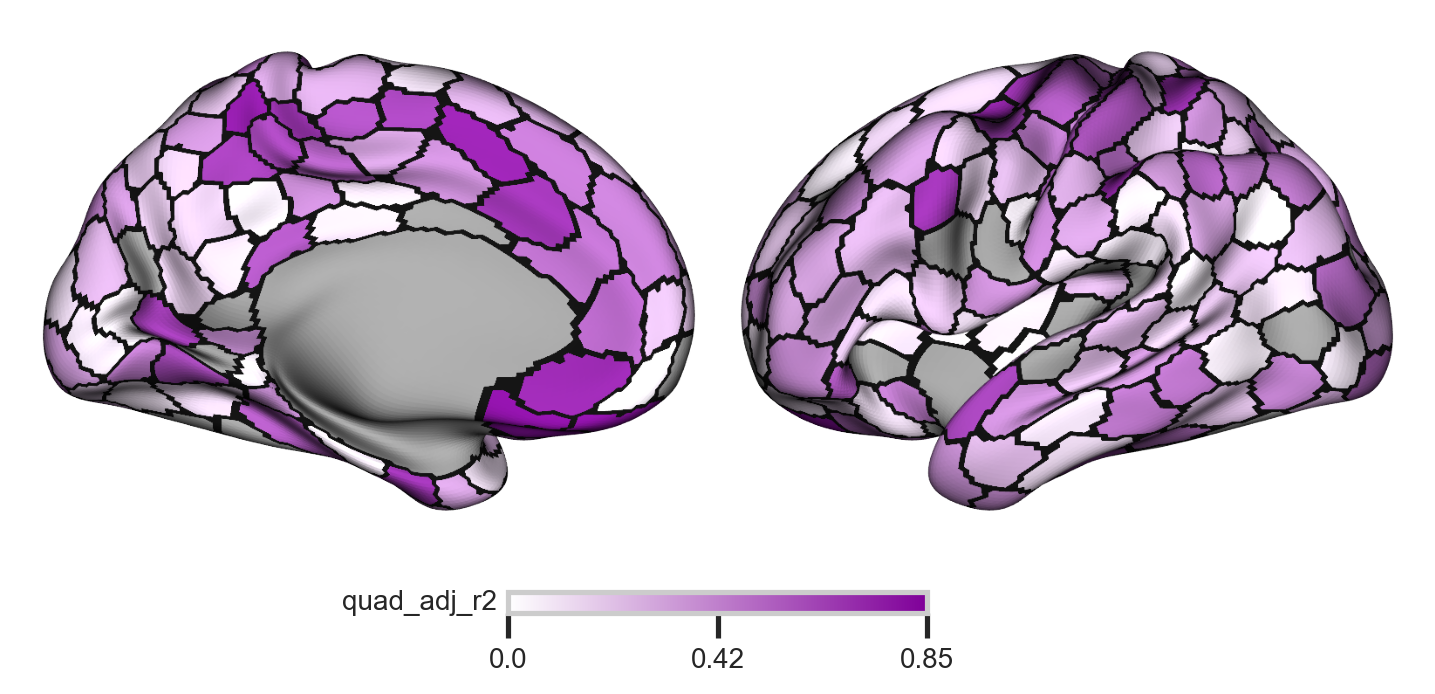

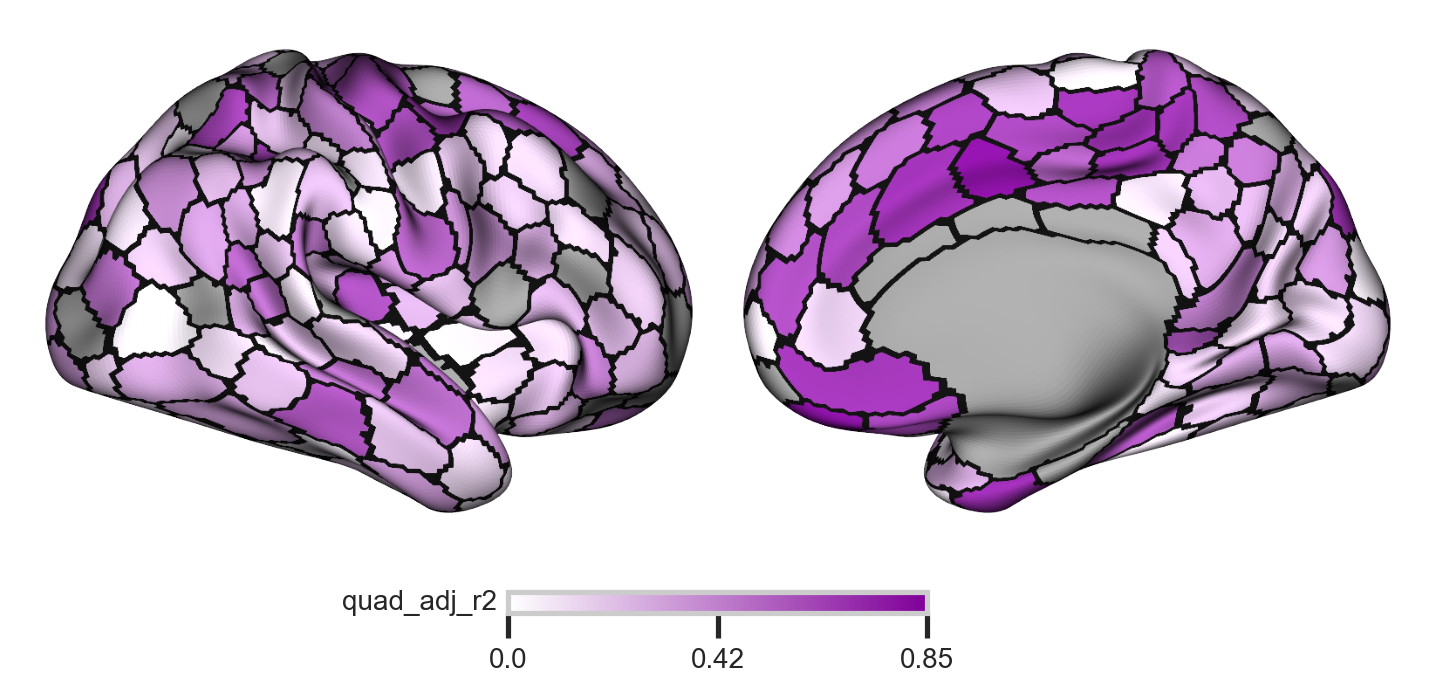

In [105]:
vmin = 0
vmax = 0.85
# vmin = -1
# vmax = 1

cmap = CMAP_WEIGHTED
# Corrected loop for plotting each hemisphere independently
for hemi_key, hemi_surf_data, mapped_data, parcellation_data in zip(
    ["left", "right"],  # The key for surfplot's dictionary
    [lh, rh],  # The surface object for the current hemisphere
    [data_lh_mapped, data_rh_mapped],  # The mapped data for the current hemisphere
    [lh_parc, rh_parc],  # The parcellation for the current hemisphere
):
    # ---------------------------------------------------------------------
    # 5.  BUILD THE PLOT
    # ---------------------------------------------------------------------
    pref_surf = {
        "surf_lh": hemi_surf_data if hemi_key == "left" else None,
        "surf_rh": hemi_surf_data if hemi_key == "right" else None,
    }

    views = ["lateral", "medial"] if hemi_key == "right" else ["medial", "lateral"]
    p = Plot(
        **pref_surf,  # Unpack the surface dictionary
        views=views,  # Show both medial and lateral for this hemi
        size=(800, 300),  # px; change as needed
        zoom=1.6,
        layout="row",  # For a single hemisphere, row is fine
        mirror_views=False,  # Set to False, as we are plotting one hemi at a time
    )

    # ---- main data layer -------------------------------------------------
    # Pass only the data for the current hemisphere
    # The dictionary now contains only one key-value pair for the current hemisphere
    p.add_layer(
        {hemi_key: mapped_data},
        cmap=cmap,
        # cmap="coolwarm",
        color_range=(vmin, vmax),  # Use symmetric range
        # norm=norm,  # Apply the symmetric normalization
        cbar_label=value_column,
        cbar=True,  # Ensure colorbar is shown for each plot if desired, or handle globally
    )
    # ---- outline layer ---------------------------------------------------
    p.add_layer({hemi_key: parcellation_data}, cmap="gray", as_outline=True, cbar=False)

    fig = p.build(
        # cbar_kws=dict(location="bottom", decimals=2, shrink=0.6)
    )  # Added cbar_kws for better cbar display
    # savefig_nice(
    #     fig,
    #     OUTPUT_DIR / f"{hemi_key}_{key}.png",
    #     # tight=True,
    #     dpi=400,
    # )

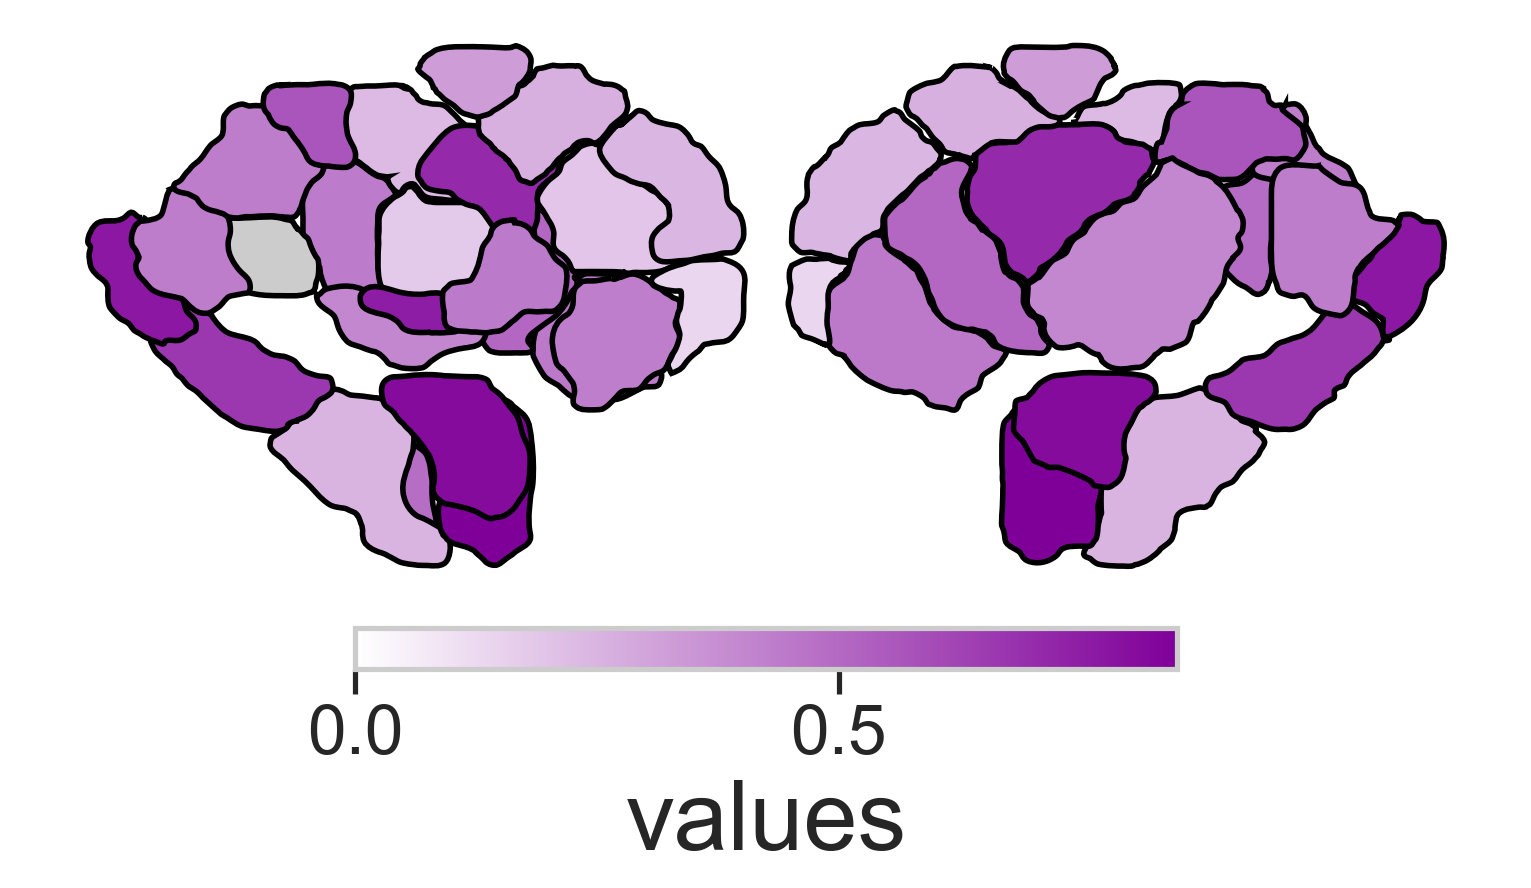

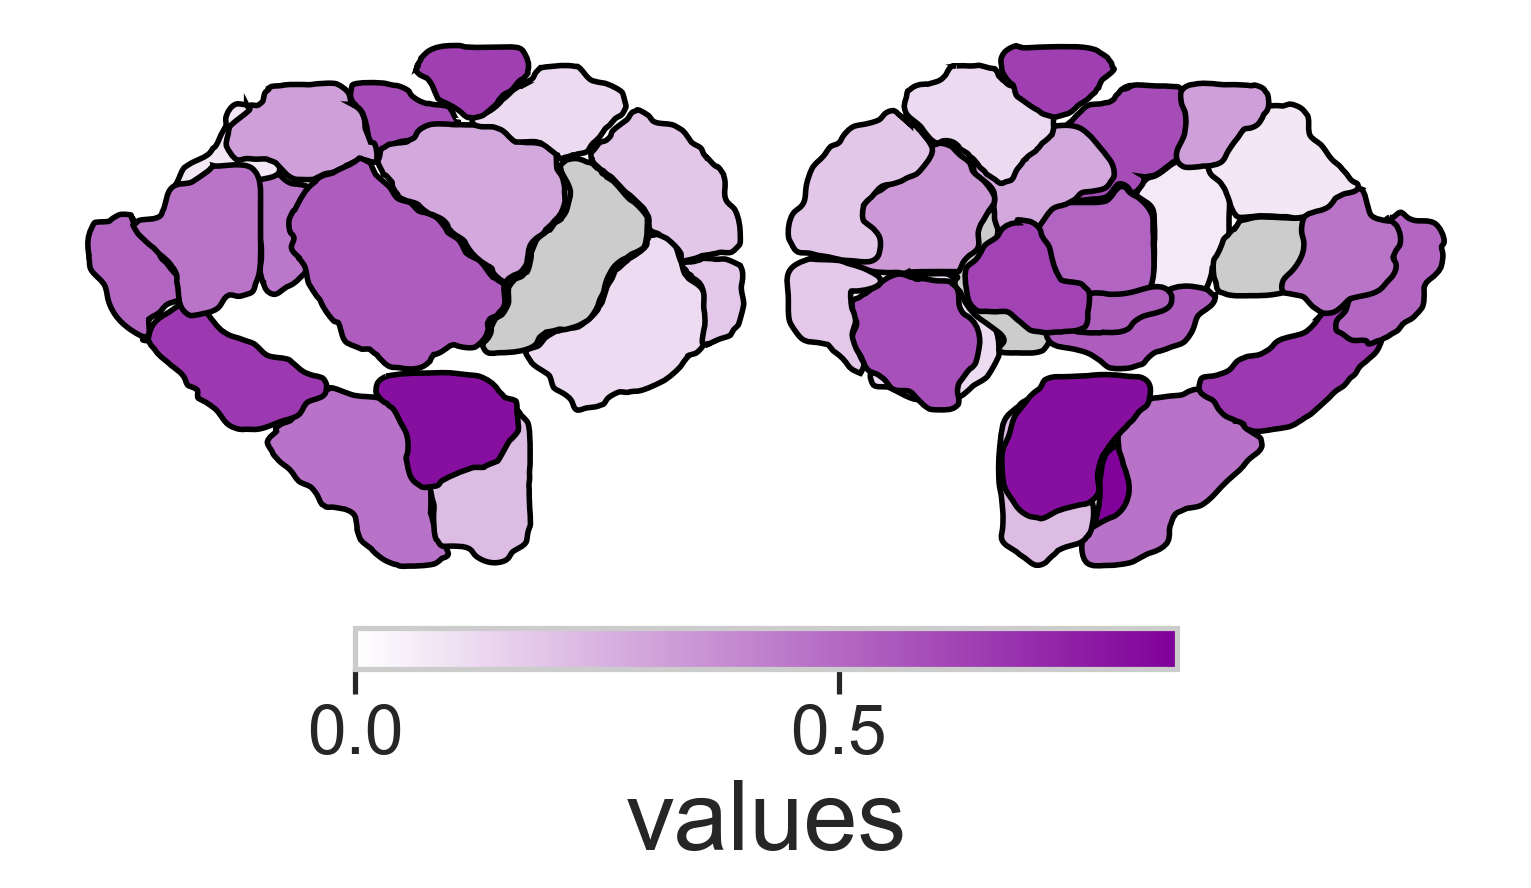

In [106]:
from subcortex_visualization.plotting import plot_subcortical_data

subcort_df = pd.DataFrame(value_map_subcortex)
if "schaefer" in ATLAS:
    subcort_df["region"] = subcort_df["region"] - int(ATLAS.split("_")[1])


for hemi in ["L", "R"]:

    fig = plot_subcortical_data(
        subcort_df,
        atlas="Melbourne_S3",
        show_legend=True,
        hemisphere=hemi,
        cmap=cmap,
        # cmap="coolwarm",
        line_color="black",
        line_thickness=2,
        vmin=vmin,
        vmax=vmax,
        show_figure=False,
    )

    # save figure
    # savefig_nice(
    #     fig,
    #     OUTPUT_DIR / f"subcortical_{hemi}_{key}.png",
    #     # tight=True,
    #     dpi=400,
    # )
    # savefig_nice(fig, OUTPUT_DIR / f"fig2_subcort_{metric}_{hemi}_{value_column}.png", dpi=400)

In [107]:
raise SystemExit("Done with plotting, exiting script.")

SystemExit: Done with plotting, exiting script.

/home/galkepler/Projects/neuroaging/venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3707: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [52]:
import matplotlib.colors as mcolors

key = "strength"  # or "betweenness", "clustering"
# comp_stats = {}
# for m in ["gm_vol","adc"]:
#     comp_stats[m] = pd.read_csv(OUTPUT_DIR.parent / m / f"{key}.csv")
#     comp_stats[m]

df_gm_strength = pd.read_csv(OUTPUT_DIR.parent / "gm_vol" / f"{key}.csv")
df_md_strength = pd.read_csv(OUTPUT_DIR.parent / "adc" / f"{key}.csv")

# --- Prepare DataFrames for merging and extracting quadratic R2 ---
df_gm_r2 = df_gm_strength[["name", "quad_adj_r2", "quad_pval_adj"]].copy()
df_gm_r2.rename(
    columns={"quad_adj_r2": "gm_quad_adj_r2", "quad_pval_adj": "gm_quad_pval_adj"}, inplace=True
)

df_md_r2 = df_md_strength[["name", "quad_adj_r2", "quad_pval_adj"]].copy()
df_md_r2.rename(
    columns={"quad_adj_r2": "md_quad_adj_r2", "quad_pval_adj": "md_quad_pval_adj"}, inplace=True
)

# Merge the DataFrames based on region name (assuming 'name' is the common identifier)
merged_r2_df = pd.merge(df_gm_r2, df_md_r2, on="name", how="outer")

# Handle NaNs: If a region exists in one file but not the other, treat its R2 as 0
merged_r2_df.fillna(value=0.0, inplace=True)  # Assume R2=0 if data is missing for a metric

# --- Calculate the 'Dominance Score' ---
# Score ranges from negative (GM dominant) to positive (MD dominant)
merged_r2_df["dominance_score"] = merged_r2_df["md_quad_adj_r2"] - merged_r2_df["gm_quad_adj_r2"]

# --- Handle 'Neither' (low R2 for both) regions ---
# Define a threshold for what constitutes a "weak" R2 association (e.g., R2 < 0.1 for both)
# You may need to adjust this threshold based on your R2 distribution
# weak_r2_threshold = 0.05 # For example, if R2 < 0.05 is considered very weak/non-meaningful
merged_r2_df["is_neither_strong"] = (merged_r2_df["gm_quad_pval_adj"] > p_threshold) & (
    merged_r2_df["md_quad_pval_adj"] > p_threshold
)

# Set the dominance score to NaN for 'neither' regions, so surfplot can color them separately
merged_r2_df.loc[merged_r2_df["is_neither_strong"], "dominance_score"] = np.nan

In [53]:
from math import isclose
import matplotlib.colors as mcolors

vis_df = parcels.copy()
vis_df["dominance_score"] = merged_r2_df[
    "dominance_score"
].values.tolist()  # Assign the composite R2 values
# colorize regions by ["only adc","only gm_vol", "both"] (for "both", use the combination of the two colors)
# --- Assign numerical values to each region based on quadratic significance ---

# for index, row in vis_df.iterrows():
#     is_gm_quad_sig = comp_stats['gm_vol'].loc[index, 'quad_pval_adj'] < p_threshold
#     is_md_quad_sig = comp_stats['adc'].loc[index, 'quad_pval_adj'] < p_threshold
#     numerical_value = np.nan # Default: Neither
#     if is_gm_quad_sig and is_md_quad_sig:
#         numerical_value = 3 # Both
#     elif is_gm_quad_sig:
#         numerical_value = 1 # GM only
#     elif is_md_quad_sig:
#         numerical_value = 2 # MD only

#     vis_df.at[index, 'association'] = numerical_value

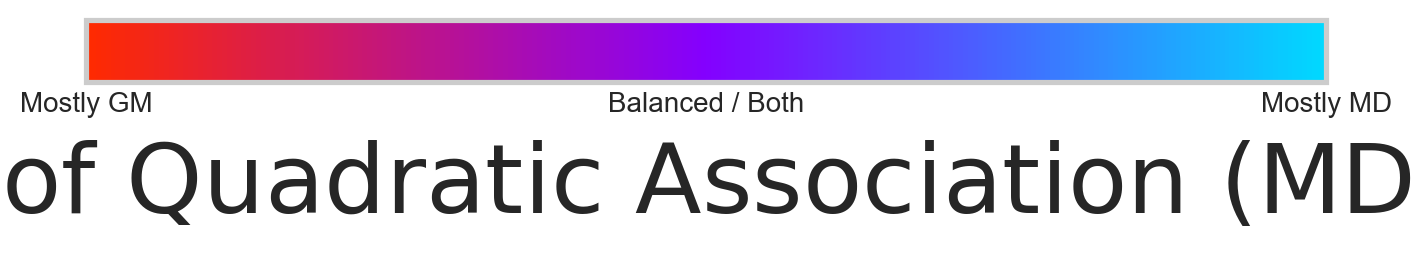

In [54]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# --- Re-define the custom colormap and relevant values (assuming previous code was run) ---
# Define the colors for the diverging scale
color_gm_dominant = "#FF2A00"  # Soft Coral/Rust (for mostly GM)
color_balanced = "#8400FF"  # Blue Violet (for balanced/both)
color_md_dominant = "#00D9FF"  # Teal Blue (for mostly MD)
neither_strong_color = "#A9A9A9"  # Dark Gray for 'neither'

# Create a LinearSegmentedColormap
cmap_colors = [(0.0, color_gm_dominant), (0.5, color_balanced), (1.0, color_md_dominant)]
custom_diverging_cmap = mcolors.LinearSegmentedColormap.from_list("DominanceCmap", cmap_colors)

# Set the NaN color for the colormap (for regions where both R2 are weak)
# This is handled by setting 'bad' color for the colormap.
custom_diverging_cmap.set_bad(neither_strong_color)

# Assume vmin, vmax from previous calculation (from the dominance_score range)
# Example values, replace with your actual vmin/vmax if not running the full pipeline
# These should be symmetric around 0, covering the full range of your 'dominance_score'
vmin = -0.7  # Example based on typical R2 differences
vmax = 0.7  # Example based on typical R2 differences

# --- Create a dummy plot to attach the colorbar to ---
# In your actual brain map plotting, you would replace this with your plot_stat_map or similar.
fig, ax = plt.subplots(
    figsize=(8, 8), facecolor="white"
)  # Using white background for demonstration

# Create a dummy mappable object with a range that includes NaNs for demonstration
# This is to show how 'nan_color' works on the colorbar if data has NaNs.
dummy_data = np.linspace(vmin, vmax, 100).reshape(1, -1)
dummy_data[:, ::10] = np.nan  # Introduce some NaNs for demonstration

cax = ax.imshow(dummy_data, cmap=custom_diverging_cmap, vmin=vmin, vmax=vmax, aspect="auto")
ax.set_visible(False)  # Hide the dummy axes for cleaner colorbar demo

# --- Create the custom colorbar ---
# Tick locations: at vmin, 0, and vmax to show the diverging points
tick_locations = [vmin, 0, vmax]

# Tick labels: descriptive for the range
tick_labels = ["Mostly GM", "Balanced / Both", "Mostly MD"]

# Create the colorbar using the mappable from imshow
cbar = fig.colorbar(cax, ticks=tick_locations, orientation="horizontal", ax=ax, extend="neither")
cbar.set_ticklabels(tick_labels)
cbar.set_label(
    "Dominance of Quadratic Association (MD $R^2$ - GM $R^2$)"
)  # Label for the colorbar

# Optional: Adjust colorbar appearance
cbar.ax.tick_params(labelsize=10)  # Font size of tick labels
cbar.ax.tick_params(length=0)  # Remove tick marks for a cleaner categorical-like look

plt.show()

In [55]:
for i, row in vis_df.iterrows():
    label = row[region_col]
    hemi_row = row["hemisphere"]  # Get hemisphere from your DataFrame row

    # Apply thresholds
    value = vis_df.loc[i, "dominance_score"]  # Use the composite R2 value directly

    # Populate the correct hemisphere's value_map
    # Assuming your labels are global and you use the 'hemisphere' column to distinguish
    # If your Schaefer labels are already separated by hemi (e.g., 1-200 for LH, 201-400 for RH)
    # then you might only need to check the label range and not the 'hemisphere' column.
    # For Schaefer, the labels usually run 1-N for LH and N+1 - 2N for RH
    if "schaefer" in ATLAS:
        if label > int(ATLAS.split("_")[1]):
            value_map_subcortex["region"].append(label)
            value_map_subcortex["value"].append(value)
            value_map_subcortex["Hemisphere"].append(row["hemisphere"])
        else:
            if hemi_row == "L":
                value_map_lh[label] = value
            elif hemi_row == "R":
                value_map_rh[label] = value
        # Subcortex handling would go here if you were preparing for separate subcortical visualization
        # else: # This implies it's subcortical or other non-surface region
        #     value_map_subcortex["region"].append(label)
        #     value_map_subcortex["value"].append(value)
        #     value_map_subcortex["Hemisphere"].append(row["hemisphere"])

# Vectorize mapping for left and right hemispheres separately
vec_lh = np.vectorize(lambda x: value_map_lh.get(x, np.nan))
data_lh_mapped = vec_lh(lh_parc)  # Apply LH map to LH parcellation
vec_rh = np.vectorize(lambda x: value_map_rh.get(x, np.nan))
data_rh_mapped = vec_rh(rh_parc)  # Apply RH map to RH parcellation

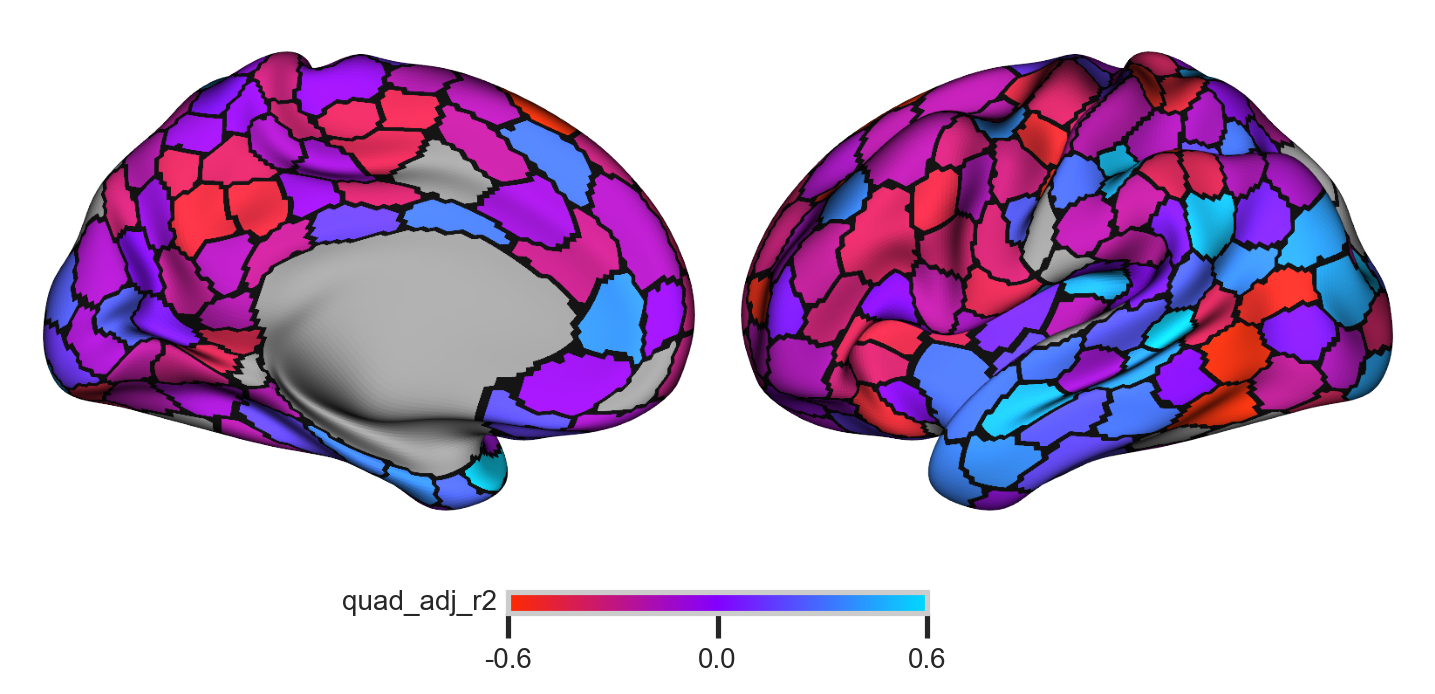

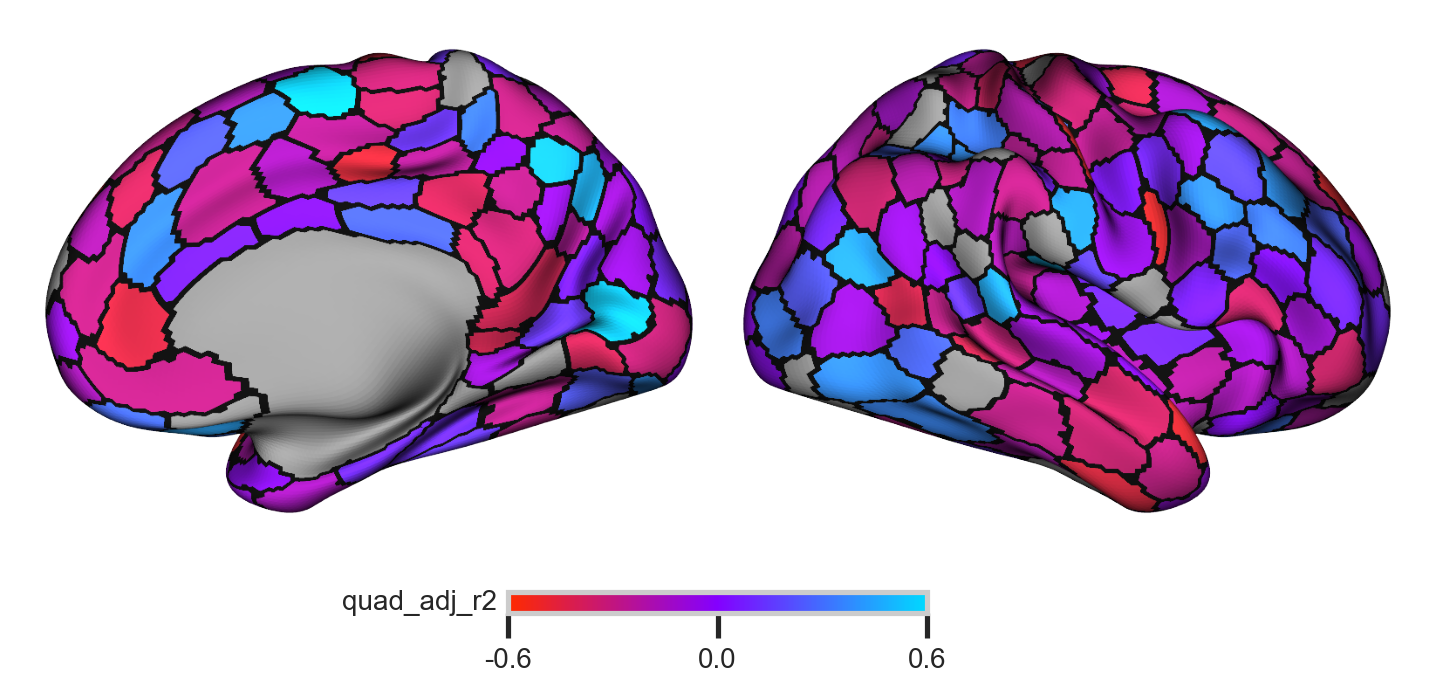

In [56]:
vmin = -0.6
vmax = 0.6


# Corrected loop for plotting each hemisphere independently
for hemi_key, hemi_surf_data, mapped_data, parcellation_data in zip(
    ["left", "right"],  # The key for surfplot's dictionary
    [lh, rh],  # The surface object for the current hemisphere
    [data_lh_mapped, data_rh_mapped],  # The mapped data for the current hemisphere
    [lh_parc, rh_parc],  # The parcellation for the current hemisphere
):
    # ---------------------------------------------------------------------
    # 5.  BUILD THE PLOT
    # ---------------------------------------------------------------------
    pref_surf = {
        "surf_lh": hemi_surf_data if hemi_key == "left" else None,
        "surf_rh": hemi_surf_data if hemi_key == "right" else None,
    }
    p = Plot(
        **pref_surf,  # Unpack the surface dictionary
        views=["medial", "lateral"],  # Show both medial and lateral for this hemi
        size=(800, 300),  # px; change as needed
        zoom=1.6,
        layout="row",  # For a single hemisphere, row is fine
        mirror_views=False,  # Set to False, as we are plotting one hemi at a time
    )

    # ---- main data layer -------------------------------------------------
    # Pass only the data for the current hemisphere
    # The dictionary now contains only one key-value pair for the current hemisphere
    p.add_layer(
        {hemi_key: mapped_data},
        cmap=custom_diverging_cmap,
        # cmap="vanimo",
        color_range=(vmin, vmax),  # Use symmetric range
        # norm=norm,  # Apply the symmetric normalization
        cbar_label=value_column,
        cbar=True,  # Ensure colorbar is shown for each plot if desired, or handle globally
    )
    # ---- outline layer ---------------------------------------------------
    p.add_layer({hemi_key: parcellation_data}, cmap="gray", as_outline=True, cbar=False)

    fig = p.build(
        # cbar_kws=dict(location="bottom", decimals=2, shrink=0.6)
    )  # Added cbar_kws for better cbar display
    # savefig_nice(
    #     fig,
    #     OUTPUT_DIR / f"{hemi_key}_{key}.png",
    #     tight=True,
    #     dpi=300,
    # )

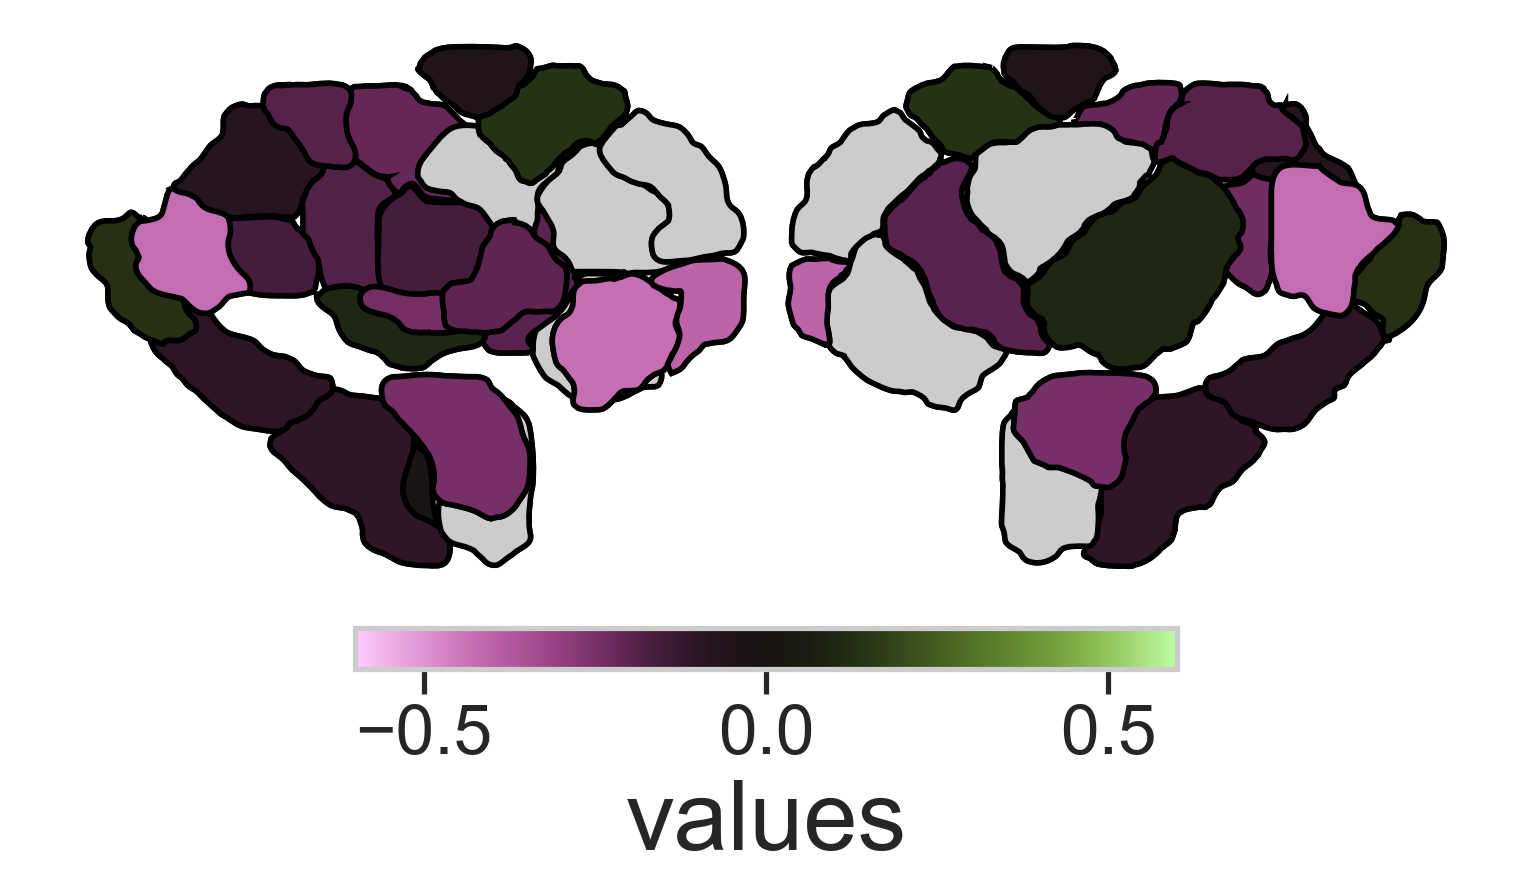

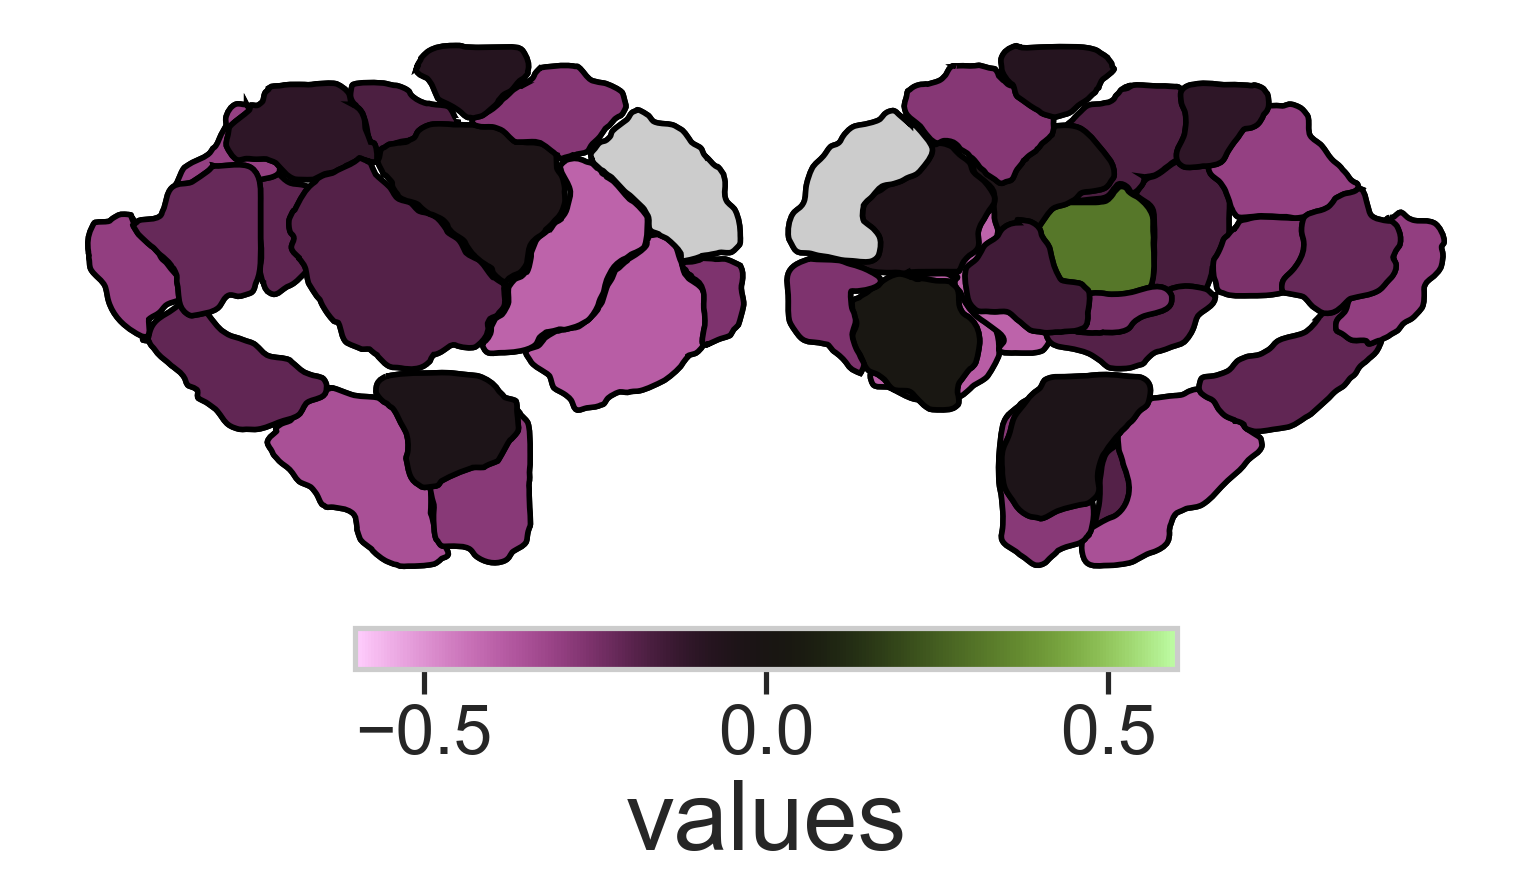

In [57]:
from subcortex_visualization.plotting import plot_subcortical_data

subcort_df = pd.DataFrame(value_map_subcortex)
if "schaefer" in ATLAS:
    subcort_df["region"] = subcort_df["region"] - int(ATLAS.split("_")[1])


for hemi in ["L", "R"]:

    fig = plot_subcortical_data(
        subcort_df,
        atlas="Melbourne_S3",
        show_legend=True,
        hemisphere=hemi,
        cmap="vanimo",
        line_color="black",
        line_thickness=2,
        vmin=vmin,
        vmax=vmax,
        show_figure=False,
    )

    # save figure
    # savefig_nice(
    #     fig,
    #     OUTPUT_DIR / f"subcortical_{hemi}_{key}.png",
    #     tight=True,
    #     dpi=300,
    # )
    # savefig_nice(fig, OUTPUT_DIR / f"fig2_subcort_{metric}_{hemi}_{value_column}.png", dpi=400)